# 导入所需模块

In [4]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report,roc_curve

In [5]:
# 忽略警告信息
warnings.filterwarnings('ignore')

# ============ 全局中文字体设置 ============
# 设置matplotlib支持中文显示（此设置对整个notebook生效）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 中文字体列表
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

print("✓ 全局配置完成：中文字体已设置")

✓ 全局配置完成：中文字体已设置


# 加载数据集为DataFrame格式

In [6]:
df=pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# 从数据集中提取有用信息

In [7]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


# 分类前的预处理

In [10]:
df=df.drop(columns=['Unnamed: 32','id'])
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 检查缺失值

In [11]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

# 发现数据质量良好，没有空值

In [12]:
df=pd.get_dummies(df,drop_first=True,columns=['diagnosis'],dtype=int)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [13]:
# 排除目标变量
columns = [c for c in df.columns if c != 'diagnosis_M']

# 查找异常值

### 可视化：异常值处理前的箱线图

注意：已设置中文字体以确保图表中的中文能正常显示。


In [14]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


## 异常值检测与处理

我们使用 **IQR（四分位距）法** 处理数据中的异常值。

### 处理步骤：

1. **计算四分位数**：
   - Q1：第一四分位数（25%分位数）
   - Q3：第三四分位数（75%分位数）
   - IQR = Q3 - Q1（四分位距）

2. **确定异常值边界**：
   - 下界 = Q1 - 1.5 × IQR
   - 上界 = Q3 + 1.5 × IQR

3. **异常值判定**：
   - 小于下界的值 → 异常值（过小）
   - 大于上界的值 → 异常值（过大）

4. **处理方法**：采用截断法（Clipping），将超出范围的值替换为边界值
   - 值 < 下界 → 替换为下界值
   - 值 > 上界 → 替换为上界值
   - 正常范围内的值保持不变


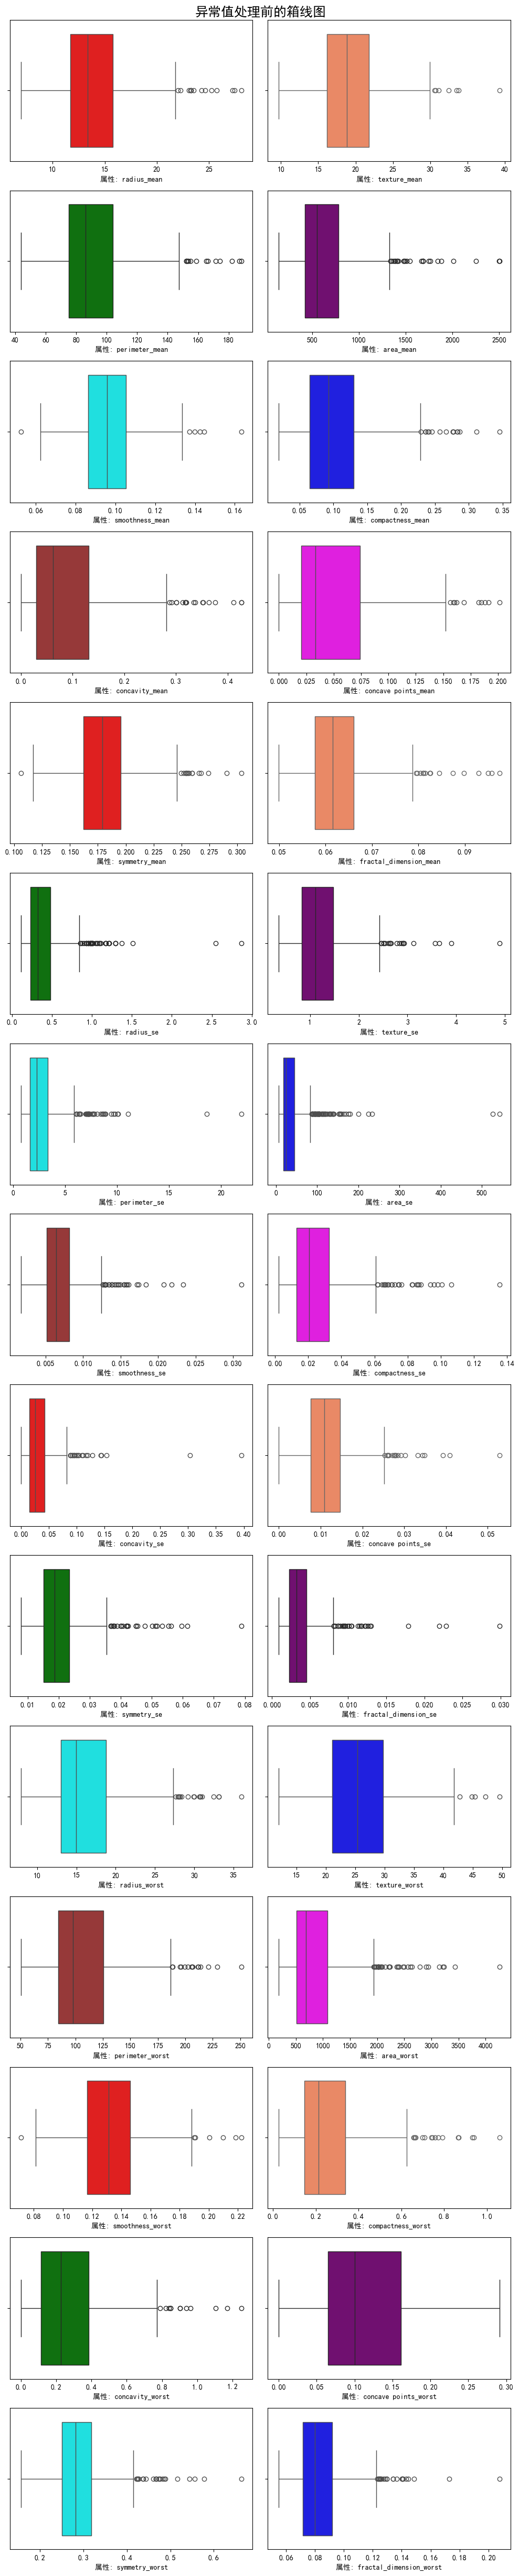

In [15]:
# 确保中文正常显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig,axes=plt.subplots(15,2,figsize=(10,50))
axes=axes.flatten()
colour=['red','coral','green','purple','cyan','blue','brown','magenta']*4

for index in range(len(columns)):
    sns.boxplot(x=df[columns[index]],color=colour[index],ax=axes[index])
    axes[index].set_xlabel(f"属性: {columns[index]}", fontweight='bold')
plt.suptitle("异常值处理前的箱线图\n\n\n", fontweight='bold', fontsize=18)
plt.tight_layout()
plt.show()

# 异常值处理函数

In [16]:
def outlier_removal(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1

    lower_bound,upper_bound=Q1-1.5*IQR,Q3+1.5*IQR
    df[column]=df[column].clip(lower=lower_bound,upper=upper_bound)

### 可视化：异常值处理后的箱线图


In [17]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [18]:
for column in columns:
    outlier_removal(column)

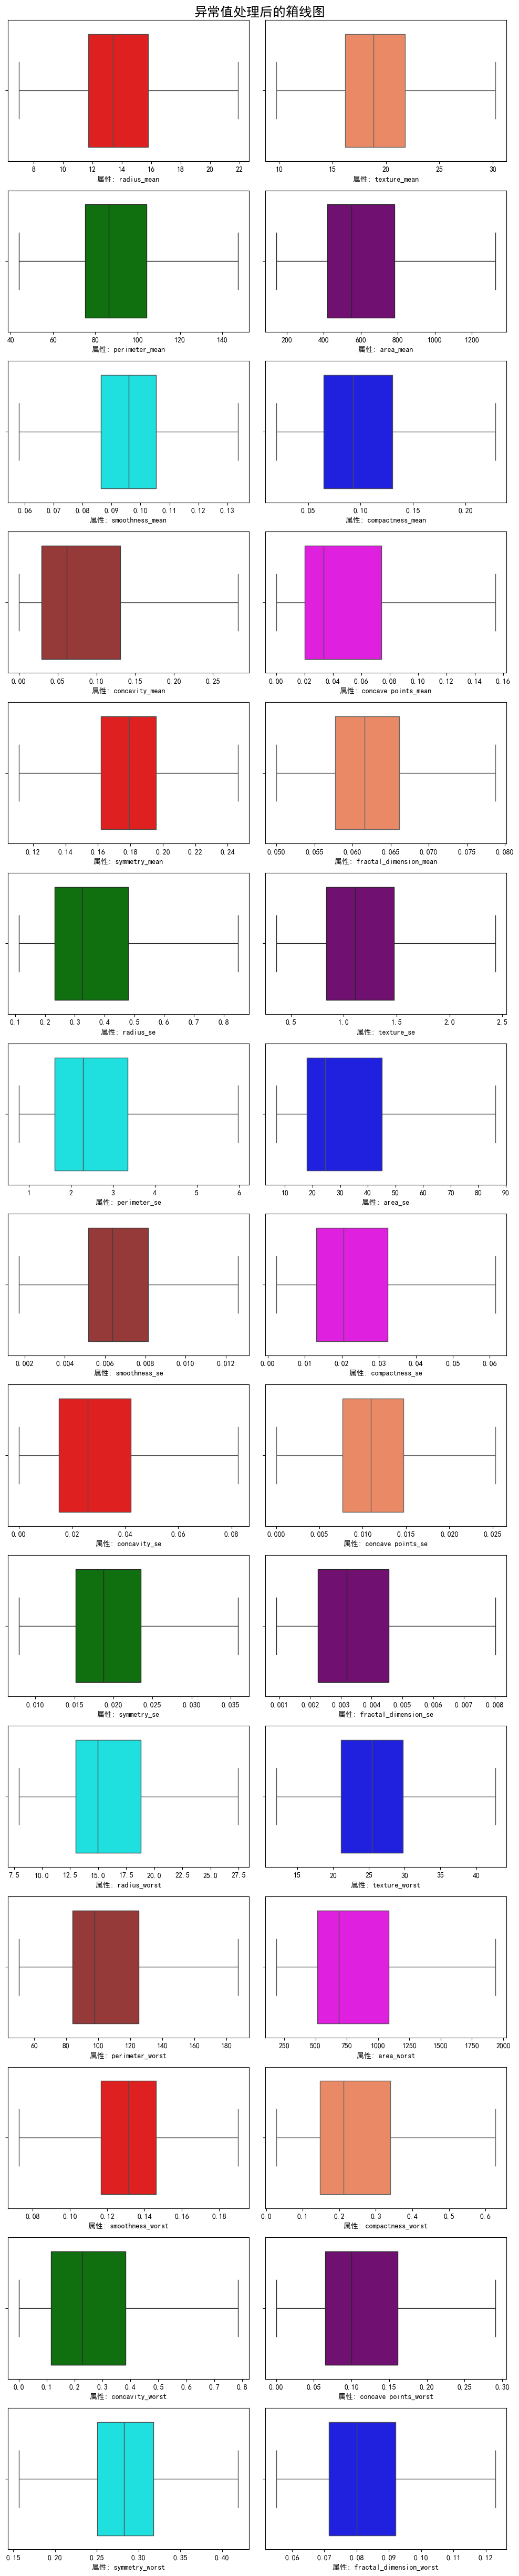

In [19]:
fig,axes=plt.subplots(15,2,figsize=(10,50))
axes=axes.flatten()
colour=['red','coral','green','purple','cyan','blue','brown','magenta']*4

for index in range(len(columns)):
    sns.boxplot(x=df[columns[index]],color=colour[index],ax=axes[index])
    axes[index].set_xlabel(f"属性: {columns[index]}", fontweight='bold')
plt.suptitle("异常值处理后的箱线图\n\n\n", fontweight='bold', fontsize=18)
plt.tight_layout()
plt.show()

# 异常值移除完成

In [20]:
target=df['diagnosis_M']
df=df.drop(columns=['diagnosis_M'])
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,1937.05,0.1622,0.62695,0.7119,0.2654,0.41915,0.11890
1,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1937.05,0.1238,0.18660,0.2416,0.1860,0.27500,0.08902
2,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.00,0.1444,0.42450,0.4504,0.2430,0.36130,0.08758
3,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,0.07875,...,14.91,26.50,98.87,567.70,0.1901,0.62695,0.6869,0.2575,0.41915,0.12301
4,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.00,0.1374,0.20500,0.4000,0.1625,0.23640,0.07678


# 数据标准化

In [21]:
scaler=StandardScaler()
df=pd.DataFrame(scaler.fit_transform(df),columns=df.columns)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.176800,-2.121200,1.357375,1.184085,1.618861,2.541404,2.647422,2.620973,2.348535,2.511708,...,2.006477,-1.375159,2.439568,2.287627,1.344848,2.641905,2.246192,2.296076,2.443918,2.225247
1,1.949929,-0.354875,1.795991,2.249396,-0.842995,-0.498189,-0.000497,0.574944,0.017882,-0.925449,...,1.921384,-0.370048,1.631542,2.287627,-0.377098,-0.443388,-0.137634,1.087084,-0.234408,0.355314
2,1.686226,0.476899,1.670052,1.846217,0.975239,1.148680,1.496076,2.110330,1.004666,-0.407692,...,1.611558,-0.019582,1.434234,1.807751,0.546654,1.223448,0.920718,1.955000,1.369057,0.265197
3,-0.791983,0.268955,-0.606410,-0.831485,2.737521,2.541404,2.091997,1.506601,2.521318,2.517947,...,-0.277945,0.140773,-0.245395,-0.593838,2.595949,2.641905,2.119474,2.175786,2.443918,2.482456
4,1.866023,-1.174698,1.891531,2.154338,0.295047,0.599453,1.504202,1.482665,0.006363,-0.588595,...,1.386825,-1.484267,1.424838,1.525780,0.232758,-0.314469,0.665254,0.729259,-0.951602,-0.410683


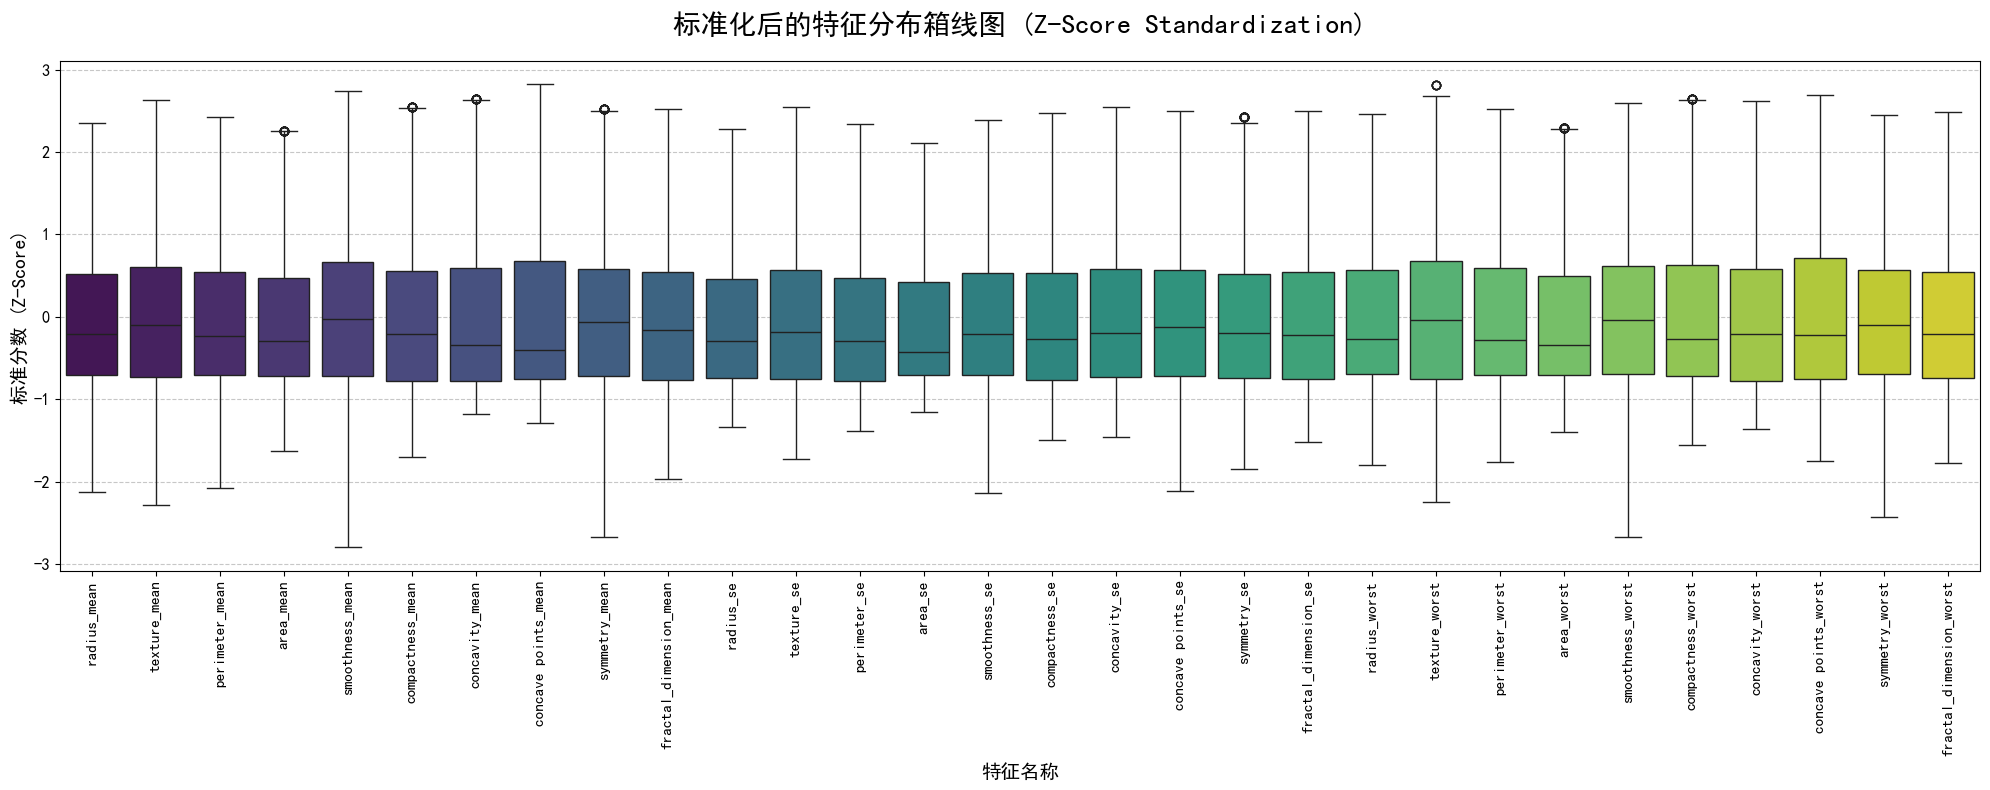

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体（确保与之前的设置一致）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置画布大小，因为有30个特征，需要宽一点
plt.figure(figsize=(20, 8))

# 绘制箱线图
# 使用 'viridis' 或 'Set2' 等配色方案，显得更具学术感
sns.boxplot(data=df, palette='viridis')

# 调整X轴标签，使其旋转90度以便阅读
plt.xticks(rotation=90, fontsize=11, fontweight='bold')
plt.yticks(fontsize=12)

# 添加标题和坐标轴标签
plt.title('标准化后的特征分布箱线图 (Z-Score Standardization)', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('标准分数 (Z-Score)', fontsize=14, fontweight='bold')
plt.xlabel('特征名称', fontsize=14, fontweight='bold')

# 添加网格线，增加可读性
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [426]:
x_train,x_test,y_train,y_test=train_test_split(df,target,random_state=42,test_size=0.3,stratify=target)

# 检查分层抽样效果

### 工作原理：

1. **按比例划分**：根据目标变量（良性/恶性）的原始比例进行划分
2. **保持平衡**：确保训练集和测试集中良性与恶性样本的比例相同
3. **避免偏差**：防止某个类别在训练集或测试集中过度代表或代表不足


通过绘制饼图对比训练集和测试集的类别分布，发现两者比例接近，说明分层抽样效果良好。

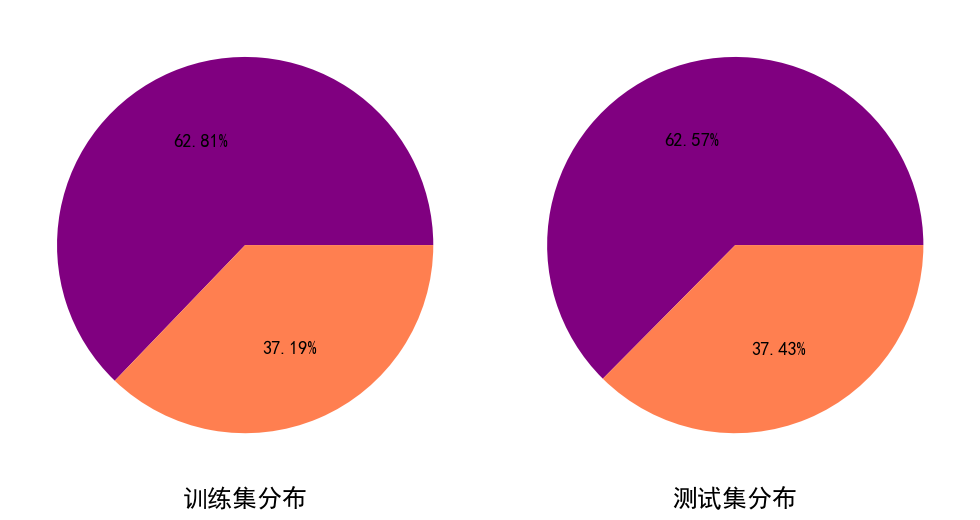

In [427]:
# 确保中文字体正常显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig,axes=plt.subplots(1,2,figsize=(10,6))

axes[0].pie(y_train.value_counts(),colors=['purple','coral'],autopct='%1.2f%%')
axes[0].set_xlabel("训练集分布",fontweight='bold', fontsize=18)

axes[1].pie(y_test.value_counts(),colors=['purple','coral'],autopct='%1.2f%%')
axes[1].set_xlabel("测试集分布",fontweight='bold', fontsize=18)

plt.tight_layout()
plt.show()

## 构建 KNN 分类模型

### 模型说明：

**K近邻算法（K-Nearest Neighbors, KNN）** 是一种基于实例的学习方法：

- **工作原理**：通过测量不同特征值之间的距离来进行分类
- **优点**：
  - 简单易懂，实现容易
  - 对异常值不敏感
  - 无需训练过程，属于懒惰学习
- **参数说明**：
  - `n_neighbors=2`：使用最近的2个邻居
  - `weights='distance'`：根据距离加权，距离越近权重越大


# 构建和训练模型

## 多模型对比分析

### 本节将对比以下6种经典分类算法：

1. **KNN（K近邻）**：基于距离的实例学习算法
2. **逻辑回归**：线性分类模型，适用于二分类问题
3. **支持向量机（SVM）**：寻找最优分类超平面
4. **决策树**：基于树形结构的分类规则
5. **随机森林**：集成多个决策树的强大模型
6. **朴素贝叶斯**：基于贝叶斯定理的概率分类器


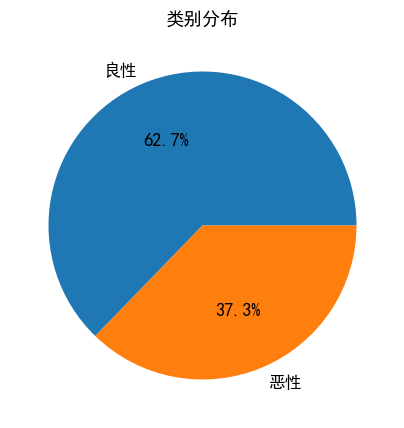

In [428]:
plt.figure(figsize=(5,5))
plt.pie(target.value_counts(), labels=['良性','恶性'], autopct='%1.1f%%')
plt.title("类别分布", fontweight='bold')
plt.show()

# 通过调用函数库训练模型

# 多模型对比实验

本节将系统性地对比6种常用的机器学习分类算法，评估它们在乳腺癌检测任务上的表现。


## 步骤 1：导入必要的库

导入数据处理、模型训练和评估所需的所有Python库。


In [429]:
# 数据处理库
import numpy as np
import pandas as pd

# 可视化库
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# sklearn 预处理和模型选择
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# sklearn 分类模型
from sklearn.neighbors import KNeighborsClassifier      # K近邻
from sklearn.linear_model import LogisticRegression     # 逻辑回归
from sklearn.svm import SVC                              # 支持向量机
from sklearn.tree import DecisionTreeClassifier          # 决策树
from sklearn.ensemble import RandomForestClassifier      # 随机森林
from sklearn.naive_bayes import GaussianNB               # 朴素贝叶斯

# sklearn 评估指标
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 忽略警告信息
warnings.filterwarnings('ignore')

# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入成功")


✓ 所有库导入成功


## 步骤 2：确认使用已处理的数据

直接使用前面已经处理好的训练集和测试集数据：
- `x_train` 和 `y_train`：训练集特征和标签
- `x_test` 和 `y_test`：测试集特征和标签

这些数据已经完成了异常值处理、标准化和分层抽样，可以直接用于模型训练。


In [430]:
# 验证之前处理的数据是否存在
try:
    print("=" * 70)
    print("检查已处理的数据...")
    print("=" * 70)
    print(f"✓ 训练集特征 (x_train)：{x_train.shape}")
    print(f"✓ 训练集标签 (y_train)：{y_train.shape}")
    print(f"✓ 测试集特征 (x_test)：{x_test.shape}")
    print(f"✓ 测试集标签 (y_test)：{y_test.shape}")
    print(f"\n✓ 数据检查完成，可以直接用于模型训练！")
    print("=" * 70)
except NameError as e:
    print(f"❌ 错误：{e}")
    print("请先运行前面的数据预处理单元格！")


检查已处理的数据...
✓ 训练集特征 (x_train)：(398, 30)
✓ 训练集标签 (y_train)：(398,)
✓ 测试集特征 (x_test)：(171, 30)
✓ 测试集标签 (y_test)：(171,)

✓ 数据检查完成，可以直接用于模型训练！


## 步骤 3：定义分类模型

创建6种不同的机器学习分类器，每种都有其特点和适用场景。


In [431]:
models_dict = {
    # 1. K近邻（KNN）：通过计算样本间距离进行分类
    #    - 优点：简单直观，适合小规模数据
    #    - 缺点：计算量大，对特征缩放敏感
    "KNN": KNeighborsClassifier(n_neighbors=2, weights='distance'),
    
    # 2. 逻辑回归：线性分类模型
    #    - 优点：训练快速，可解释性强
    #    - 缺点：只能处理线性可分问题
    "逻辑回归": LogisticRegression(random_state=42, max_iter=5000),
    
    # 3. 支持向量机（SVM）：寻找最优分类超平面
    #    - 优点：高维数据效果好，泛化能力强
    #    - 缺点：训练时间较长，参数敏感
    "支持向量机": SVC(kernel='linear', random_state=42),
    
    # 4. 决策树：基于特征阈值的树形分类规则
    #    - 优点：易于理解和可视化，无需数据预处理
    #    - 缺点：容易过拟合
    "决策树": DecisionTreeClassifier(random_state=42),
    
    # 5. 随机森林：集成多个决策树
    #    - 优点：准确率高，抗过拟合，特征重要性评估
    #    - 缺点：模型复杂，训练时间较长
    "随机森林": RandomForestClassifier(random_state=42, n_estimators=100),
    
    # 6. 朴素贝叶斯：基于贝叶斯定理的概率分类器
    #    - 优点：训练速度快，适合高维数据
    #    - 缺点：假设特征独立（现实中很少满足）
    "朴素贝叶斯": GaussianNB()
}

print(f"✓ 已定义 {len(models_dict)} 种分类模型")
for name in models_dict.keys():
    print(f"  - {name}")


✓ 已定义 6 种分类模型
  - KNN
  - 逻辑回归
  - 支持向量机
  - 决策树
  - 随机森林
  - 朴素贝叶斯


## 步骤 4：训练模型并评估性能

对每个模型进行训练，并计算以下评估指标：
- **准确率（Accuracy）**：预测正确的样本占总样本的比例
- **精确率（Precision）**：预测为恶性且实际为恶性的比例  
- **召回率（Recall）**：实际恶性中被正确预测的比例
- **F1分数（F1 Score）**：精确率和召回率的调和平均值


In [432]:
# 存储结果
results_list = []

print("=" * 85)
print(f"{'模型名称':<15} {'准确率':<12} {'精确率':<12} {'召回率':<12} {'F1分数':<12}")
print("=" * 85)

# 训练并评估每个模型
for model_name, model in models_dict.items():
    # 训练模型
    model.fit(x_train, y_train)
    
    # 预测
    y_pred = model.predict(x_test)
    
    # 计算评估指标
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # 存储结果
    results_list.append({
        "模型": model_name,
        "准确率": acc,
        "精确率": prec,
        "召回率": rec,
        "F1分数": f1
    })
    
    # 打印结果
    print(f"{model_name:<15} {acc:<12.8f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("=" * 85)

# 转换为DataFrame
results_df = pd.DataFrame(results_list)
print("\n✓ 所有模型训练和评估完成")


模型名称            准确率          精确率          召回率          F1分数        
KNN             0.95321637   0.9516       0.9219       0.9365      
逻辑回归            0.97076023   0.9836       0.9375       0.9600      
支持向量机           0.97660819   0.9839       0.9531       0.9683      
决策树             0.93567251   0.9492       0.8750       0.9106      
随机森林            0.97076023   1.0000       0.9219       0.9593      
朴素贝叶斯           0.94736842   0.9661       0.8906       0.9268      

✓ 所有模型训练和评估完成


In [433]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


## 步骤 5：可视化对比结果

通过柱状图直观展示各个模型的准确率对比。


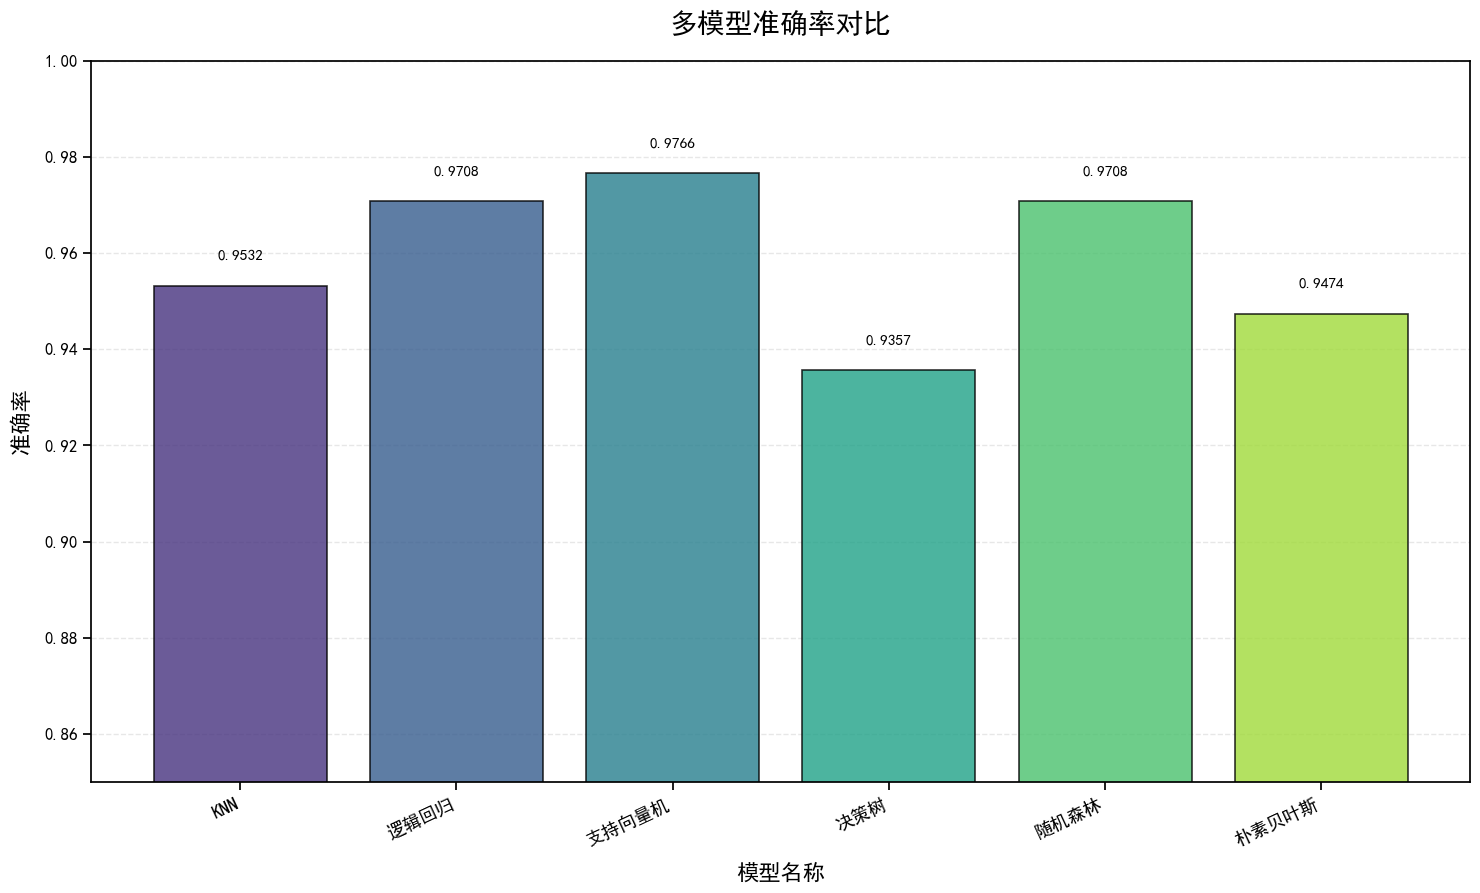

✓ 可视化完成！


In [434]:
# 2. 设置seaborn风格
# sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# 3. 创建足够大的画布（关键：留出空间显示标签）
fig = plt.figure(figsize=(15, 9))
ax = plt.subplot(111)

# 4. 使用bar而不是barplot，更好地控制样式
bars = ax.bar(results_df['模型'], results_df['准确率'], 
              color=sns.color_palette("viridis", len(results_df)),
              edgecolor='black', linewidth=1.2, alpha=0.8)

# 5. 设置标题和轴标签
ax.set_title('多模型准确率对比', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('模型名称', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('准确率', fontsize=16, fontweight='bold', labelpad=10)

# 6. 设置y轴范围
ax.set_ylim(0.85, 1.0)

# 7. 设置x轴刻度标签（关键：确保完整显示）
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['模型'].values, 
                   rotation=25,          # 25度倾斜，便于阅读
                   ha='right',           # 右对齐
                   fontsize=13,
                   weight='semibold')

# 8. 在柱子上方添加精确数值
for bar, val in zip(bars, results_df['准确率']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# 9. 美化网格线
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# 10. 调整布局，确保标签不被裁剪（重要！）
plt.tight_layout()
fig.subplots_adjust(bottom=0.12)  # 给底部更多空间

plt.show()
print("✓ 可视化完成！")


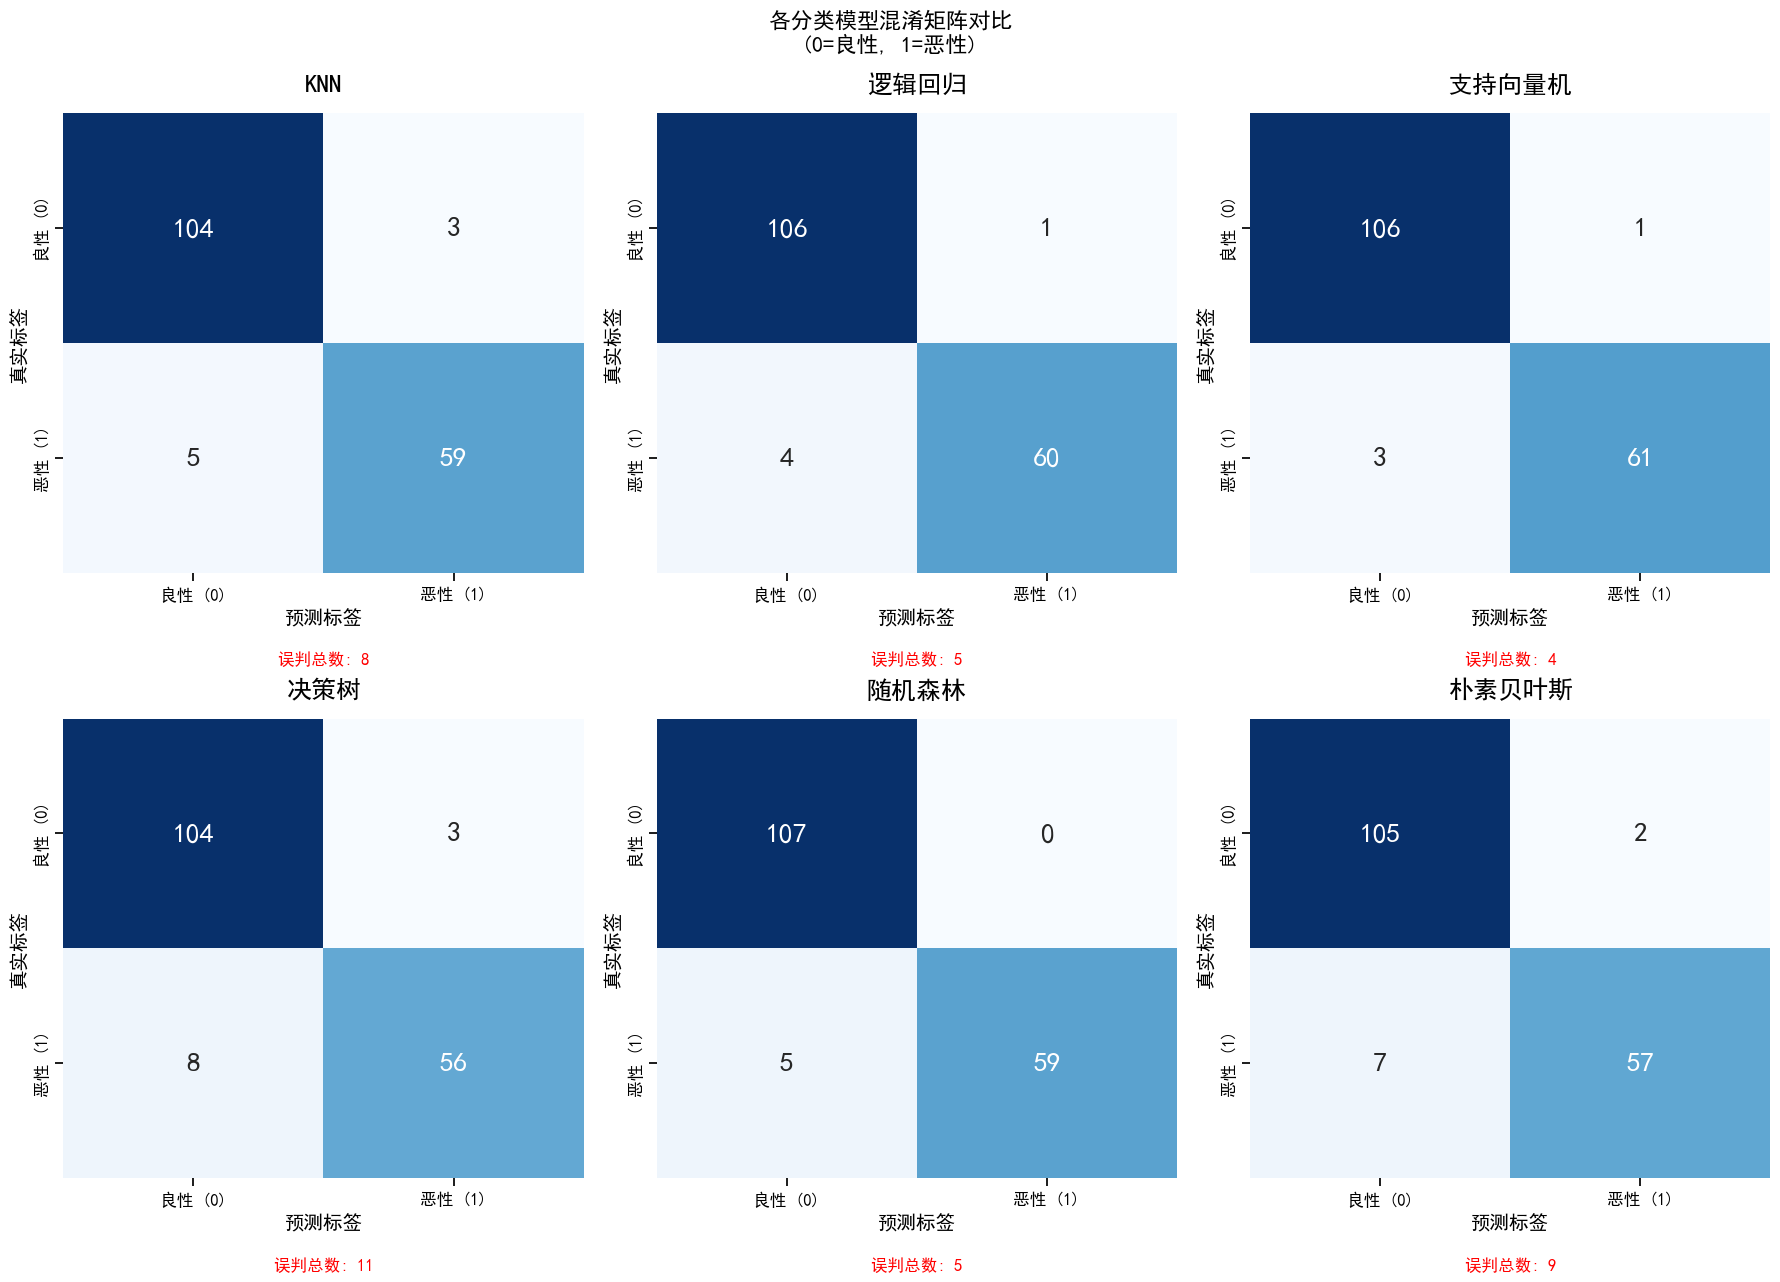

✓ 混淆矩阵绘制完成！


In [435]:
from sklearn.metrics import confusion_matrix

# 1. 设置画布大小 (2行3列)
fig, axes = plt.subplots(2, 3, figsize=(18, 13))
plt.subplots_adjust(wspace=0.3, hspace=0.4)  # 调整子图间距
axes = axes.flatten()  # 将二维数组展平，方便索引

# 2. 定义标签名称
labels = ['良性 (0)', '恶性 (1)']

# 3. 循环绘制每个模型的混淆矩阵
for i, (model_name, model) in enumerate(models_dict.items()):
    # 获取当前子图对象
    ax = axes[i]
    
    # 重新进行预测（确保数据是最新的）
    y_pred = model.predict(x_test)
    
    # 计算混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    
    # 绘制热力图
    # 使用不同的颜色主题让图表区分度更高，或者统一使用 'Blues' 保持整洁
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                annot_kws={"size": 20, "weight": "bold"}, # 字体设置
                cbar=False, # 隐藏颜色条，保持简洁
                xticklabels=labels, 
                yticklabels=labels)
    
    # 设置标题和标签
    ax.set_title(f"{model_name}", fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('预测标签', fontsize=14, fontweight='bold')
    ax.set_ylabel('真实标签', fontsize=14, fontweight='bold')
    
    # 在图表下方添加简要说明 (可选)
    ax.text(0.5, -0.2, f"误判总数: {cm[0][1] + cm[1][0]}", 
            ha='center', transform=ax.transAxes, fontsize=12, color='red')

# 4. 添加总标题
fig.suptitle('各分类模型混淆矩阵对比\n(0=良性, 1=恶性)', fontsize=16, fontweight='bold', y=0.98)

# 5. 调整布局并显示
plt.tight_layout()
# 为总标题留出空间
fig.subplots_adjust(top=0.9) 
plt.show()

print("✓ 混淆矩阵绘制完成！")

## 步骤 6：结果总结

分析实验结果，找出表现最佳的模型。


In [436]:
# 按准确率排序
results_sorted = results_df.sort_values('准确率', ascending=False)

print("\n" + "=" * 70)
print("模型性能排名（按准确率）")
print("=" * 70)
print(results_sorted.to_string(index=False))
print("=" * 70)

# 找出最佳模型
best_model = results_sorted.iloc[0]
print(f"\n🏆 表现最好的模型：{best_model['模型']}")
print(f"   - 准确率：{best_model['准确率']:.4f} ({best_model['准确率']*100:.2f}%)")
print(f"   - 精确率：{best_model['精确率']:.4f}")
print(f"   - 召回率：{best_model['召回率']:.4f}")
print(f"   - F1分数：{best_model['F1分数']:.4f}")




模型性能排名（按准确率）
   模型      准确率      精确率      召回率     F1分数
支持向量机 0.976608 0.983871 0.953125 0.968254
 逻辑回归 0.970760 0.983607 0.937500 0.960000
 随机森林 0.970760 1.000000 0.921875 0.959350
  KNN 0.953216 0.951613 0.921875 0.936508
朴素贝叶斯 0.947368 0.966102 0.890625 0.926829
  决策树 0.935673 0.949153 0.875000 0.910569

🏆 表现最好的模型：支持向量机
   - 准确率：0.9766 (97.66%)
   - 精确率：0.9839
   - 召回率：0.9531
   - F1分数：0.9683


# 手写机器学习算法实现

本节将从零开始实现支持向量机（SVM）和随机森林（Random Forest）算法，并在乳腺癌数据集上进行测试。

## 学习目标：
1. 理解SVM的数学原理和实现细节
2. 理解随机森林的集成学习思想
3. 对比手写实现与sklearn库的性能差异


In [437]:
# 手写算法所需的基础库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 手写算法模块导入完成")


✓ 手写算法模块导入完成


## 1. 手写支持向量机（SVM）

### 算法原理：
- **目标**：找到一个最优超平面，最大化两类样本之间的间隔
- **核心思想**：使用梯度下降优化目标函数
- **损失函数**：Hinge Loss + L2正则化

### 实现简化：
- 使用线性核（Linear Kernel）
- 梯度下降优化
- 支持二分类问题


In [438]:
class SimpleSVM:
    """
    简化版支持向量机实现
    使用梯度下降优化线性SVM
    """
    
    def __init__(self, learning_rate=0.0005, lambda_param=0.01, n_iterations=1000):
        """
        参数:
            learning_rate: 学习率
            lambda_param: 正则化参数（控制间隔大小）
            n_iterations: 迭代次数
        """
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iterations
        self.w = None  # 权重向量
        self.b = None  # 偏置项
        self.losses = []  # 记录损失值
        
    def fit(self, X, y):
        """
        训练SVM模型
        
        参数:
            X: 训练特征，shape (n_samples, n_features)
            y: 训练标签，shape (n_samples,)，值为0或1
        """
        n_samples, n_features = X.shape
        
        # 将标签转换为 -1 和 1（SVM标准）
        y_labeled = np.where(y <= 0, -1, 1)
        
        # 初始化参数
        self.w = np.zeros(n_features)
        self.b = 0
        
        # 梯度下降优化
        for iteration in range(self.n_iters):
            total_loss = 0
            
            for idx, x_i in enumerate(X):
                # 计算决策函数值：f(x) = w·x + b
                condition = y_labeled[idx] * (np.dot(x_i, self.w) + self.b)
                
                if condition >= 1:
                    # 正确分类且在间隔外：只更新正则化项
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                    loss = 0
                else:
                    # 分类错误或在间隔内：更新w和b
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_labeled[idx]))
                    self.b -= self.lr * (-y_labeled[idx])
                    loss = 1 - condition
                    
                total_loss += loss
            
            # 记录平均损失
            avg_loss = total_loss / n_samples
            self.losses.append(avg_loss)
            
            # 每200次迭代打印一次
            if (iteration + 1) % 200 == 0:
                print(f"  迭代 {iteration+1}/{self.n_iters}, 损失: {avg_loss:.4f}")
        
        return self
    
    def predict(self, X):
        """
        预测新样本
        
        参数:
            X: 测试特征，shape (n_samples, n_features)
            
        返回:
            预测标签，shape (n_samples,)，值为0或1
        """
        # 计算决策函数
        linear_output = np.dot(X, self.w) + self.b
        # 转换回0/1标签
        return np.where(linear_output >= 0, 1, 0)
    
    def score(self, X, y):
        """
        计算准确率
        """
        predictions = self.predict(X)
        accuracy = np.sum(predictions == y) / len(y)
        return accuracy
    
    def plot_loss(self):
        """
        绘制损失曲线
        """
        plt.figure(figsize=(10, 5))
        plt.plot(self.losses, linewidth=2)
        plt.title('SVM训练损失曲线', fontsize=16, fontweight='bold')
        plt.xlabel('迭代次数', fontsize=12)
        plt.ylabel('平均Hinge损失', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

print("✓ SimpleSVM 类定义完成")


✓ SimpleSVM 类定义完成


### 测试手写SVM

使用之前处理好的数据测试我们手写的SVM算法。


开始训练手写SVM...

手写SVM性能评估
训练集准确率: 0.9749 (97.49%)
测试集准确率: 0.9766 (97.66%)


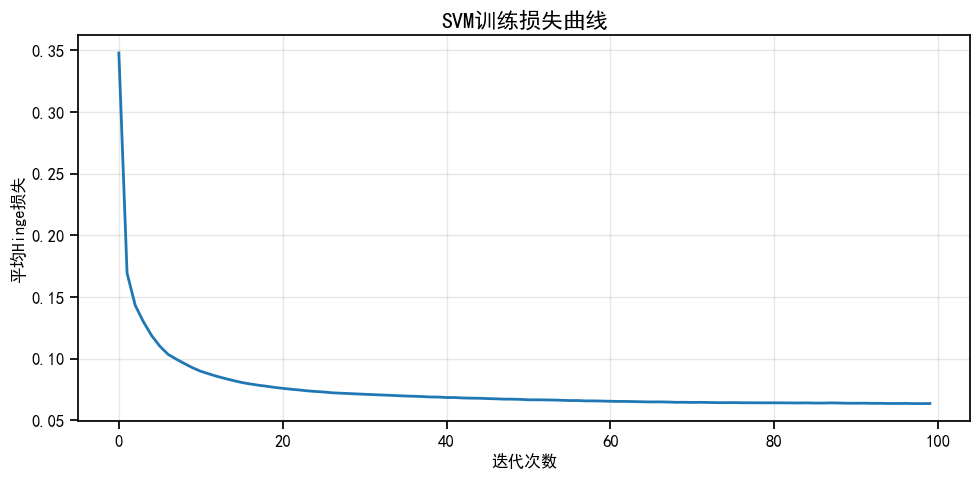

In [439]:
# 训练手写SVM
print("=" * 70)
print("开始训练手写SVM...")
print("=" * 70)

my_svm = SimpleSVM(learning_rate=0.001, lambda_param=0.01, n_iterations=100)
my_svm.fit(x_train.values, y_train.values)

# 测试性能
train_acc = my_svm.score(x_train.values, y_train.values)
test_acc = my_svm.score(x_test.values, y_test.values)

print("\n" + "=" * 70)
print("手写SVM性能评估")
print("=" * 70)
print(f"训练集准确率: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 70)

# 绘制损失曲线
my_svm.plot_loss()


## 2. 手写决策树（Decision Tree）

### 算法原理：
- **目标**：通过递归分裂构建树形结构
- **核心思想**：在每个节点选择最佳特征进行分裂
- **分裂标准**：信息增益（Information Gain）或基尼不纯度（Gini Impurity）

### 实现要点：
- 使用基尼不纯度作为分裂标准
- 支持最大深度限制防止过拟合
- 递归构建二叉树


In [440]:
class Node:
    """
    决策树节点
    """
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # 分裂特征索引
        self.threshold = threshold  # 分裂阈值
        self.left = left           # 左子树
        self.right = right         # 右子树
        self.value = value         # 叶节点的预测值


class SimpleDecisionTree:
    """
    简化版决策树实现
    使用基尼不纯度（Gini Impurity）作为分裂标准
    """
    
    def __init__(self, max_depth=10, min_samples_split=2):
        """
        参数:
            max_depth: 树的最大深度
            min_samples_split: 节点最小样本数（小于此值不再分裂）
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        
    def _gini(self, y):
        """
        计算基尼不纯度
        Gini = 1 - Σ(p_i^2)
        """
        proportions = np.bincount(y) / len(y)
        gini = 1 - np.sum(proportions ** 2)
        return gini
    
    def _split(self, X, y, feature, threshold):
        """
        根据特征和阈值分裂数据
        """
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]
    
    def _best_split(self, X, y):
        """
        找到最佳分裂点（特征和阈值）
        """
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        
        n_samples, n_features = X.shape
        
        # 遍历所有特征
        for feature in range(n_features):
            # 获取该特征的所有唯一值作为候选阈值
            thresholds = np.unique(X[:, feature])
            
            # 遍历所有阈值
            for threshold in thresholds:
                # 分裂数据
                _, _, y_left, y_right = self._split(X, y, feature, threshold)
                
                # 如果分裂后某一侧为空，跳过
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                
                # 计算加权基尼不纯度
                n = len(y)
                gini_left = self._gini(y_left)
                gini_right = self._gini(y_right)
                weighted_gini = (len(y_left) / n) * gini_left + (len(y_right) / n) * gini_right
                
                # 更新最佳分裂
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    def _build_tree(self, X, y, depth=0):
        """
        递归构建决策树
        """
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # 停止条件
        if depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split:
            # 创建叶节点，值为众数
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
        # 找到最佳分裂
        best_feature, best_threshold = self._best_split(X, y)
        
        # 如果找不到有效分裂，创建叶节点
        if best_feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
        
        # 分裂数据
        X_left, X_right, y_left, y_right = self._split(X, y, best_feature, best_threshold)
        
        # 递归构建左右子树
        left = self._build_tree(X_left, y_left, depth + 1)
        right = self._build_tree(X_right, y_right, depth + 1)
        
        return Node(feature=best_feature, threshold=best_threshold, left=left, right=right)
    
    def fit(self, X, y):
        """
        训练决策树
        """
        self.root = self._build_tree(X, y)
        return self
    
    def _predict_one(self, x, node):
        """
        预测单个样本
        """
        # 如果是叶节点，返回预测值
        if node.value is not None:
            return node.value
        
        # 根据特征值决定走左子树还是右子树
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
    
    def predict(self, X):
        """
        预测多个样本
        """
        return np.array([self._predict_one(x, self.root) for x in X])
    
    def score(self, X, y):
        """
        计算准确率
        """
        predictions = self.predict(X)
        accuracy = np.sum(predictions == y) / len(y)
        return accuracy

print("✓ SimpleDecisionTree 类定义完成")


✓ SimpleDecisionTree 类定义完成


## 3. 手写随机森林（Random Forest）

### 算法原理：
- **目标**：集成多个决策树，通过投票提高准确率
- **核心思想**：Bagging（自助聚合）+ 随机特征选择
- **关键技术**：
  - Bootstrap采样：有放回地随机采样训练数据
  - 随机特征：每次分裂时随机选择特征子集
  - 多数投票：综合所有树的预测结果

### 为什么使用随机森林？
- 降低过拟合风险（相比单个决策树）
- 提高模型稳定性和准确率
- 能够评估特征重要性


In [441]:
class SimpleRandomForest:
    """
    简化版随机森林实现
    集成多个决策树
    """
    
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2):
        """
        参数:
            n_trees: 森林中树的数量
            max_depth: 每棵树的最大深度
            min_samples_split: 节点最小样本数
        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        
    def _bootstrap_sample(self, X, y):
        """
        Bootstrap采样：有放回地随机采样
        """
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]
    
    def fit(self, X, y):
        """
        训练随机森林
        """
        self.trees = []
        
        for i in range(self.n_trees):
            # 创建决策树
            tree = SimpleDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            
            # Bootstrap采样
            X_sample, y_sample = self._bootstrap_sample(X, y)
            
            # 训练树
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
            if (i + 1) % 10 == 0:
                print(f"  已训练 {i+1}/{self.n_trees} 棵树")
        
        return self
    
    def predict(self, X):
        """
        预测：多数投票
        """
        # 获取所有树的预测
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        
        # 对每个样本进行多数投票
        # tree_predictions shape: (n_trees, n_samples)
        # 转置后 shape: (n_samples, n_trees)
        tree_predictions = tree_predictions.T
        
        # 每行取众数
        predictions = [Counter(tree_pred).most_common(1)[0][0] for tree_pred in tree_predictions]
        
        return np.array(predictions)
    
    def score(self, X, y):
        """
        计算准确率
        """
        predictions = self.predict(X)
        accuracy = np.sum(predictions == y) / len(y)
        return accuracy

print("✓ SimpleRandomForest 类定义完成")


✓ SimpleRandomForest 类定义完成


### 测试手写随机森林

使用之前处理好的数据测试我们手写的随机森林算法。


In [442]:
# 训练手写随机森林
print("=" * 70)
print("开始训练手写随机森林（50棵树）...")
print("=" * 70)

my_rf = SimpleRandomForest(n_trees=50, max_depth=10, min_samples_split=2)
my_rf.fit(x_train.values, y_train.values)

# 测试性能
train_acc1 = my_rf.score(x_train.values, y_train.values)
test_acc1 = my_rf.score(x_test.values, y_test.values)

print("\n" + "=" * 70)
print("手写随机森林性能评估")
print("=" * 70)
print(f"训练集准确率: {train_acc1:.4f} ({train_acc1*100:.2f}%)")
print(f"测试集准确率: {test_acc1:.4f} ({test_acc1*100:.2f}%)")
print("=" * 70)


开始训练手写随机森林（50棵树）...
  已训练 10/50 棵树
  已训练 20/50 棵树
  已训练 30/50 棵树
  已训练 40/50 棵树
  已训练 50/50 棵树

手写随机森林性能评估
训练集准确率: 1.0000 (100.00%)
测试集准确率: 0.9766 (97.66%)


## 4. 对比sklearn库实现

下面将手写算法与sklearn库中的标准实现进行性能对比。


In [443]:
# 导入sklearn的实现
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

print("=" * 85)
print("开始训练sklearn版本的SVM和随机森林...")
print("=" * 85)

# 训练sklearn的SVM
sklearn_svm = SVC(kernel='linear', random_state=42)
sklearn_svm.fit(x_train, y_train)
sklearn_svm_acc = sklearn_svm.score(x_test, y_test)

# 训练sklearn的随机森林
sklearn_rf = RandomForestClassifier(random_state=42, n_estimators=100)
sklearn_rf.fit(x_train, y_train)
sklearn_rf_acc = sklearn_rf.score(x_test, y_test)

# 对比结果
print("\n" + "=" * 85)
print(f"{'算法':<25} {'手写实现准确率':<20} {'sklearn准确率':<20} {'差距':<10}")
print("=" * 85)
print(f"{'支持向量机 (SVM)':<25} {test_acc:.4f} ({test_acc*100:.2f}%){'':<6} {sklearn_svm_acc:.4f} ({sklearn_svm_acc*100:.2f}%){'':<6} {abs(test_acc-sklearn_svm_acc):.4f}")

# 保存之前的test_acc为my_svm_acc
my_svm_acc = test_acc

# 获取随机森林的test_acc
my_rf_acc = my_rf.score(x_test.values, y_test.values)
print(f"{'随机森林 (RF)':<25} {my_rf_acc:.4f} ({my_rf_acc*100:.2f}%){'':<6} {sklearn_rf_acc:.4f} ({sklearn_rf_acc*100:.2f}%){'':<6} {abs(my_rf_acc-sklearn_rf_acc):.4f}")
print("=" * 85)

print("\n✅ 对比完成！")


开始训练sklearn版本的SVM和随机森林...

算法                        手写实现准确率              sklearn准确率           差距        
支持向量机 (SVM)               0.9766 (97.66%)       0.9766 (97.66%)       0.0000
随机森林 (RF)                 0.9766 (97.66%)       0.9708 (97.08%)       0.0058

✅ 对比完成！


### 可视化对比结果

绘制柱状图直观展示手写实现与sklearn实现的性能差异。


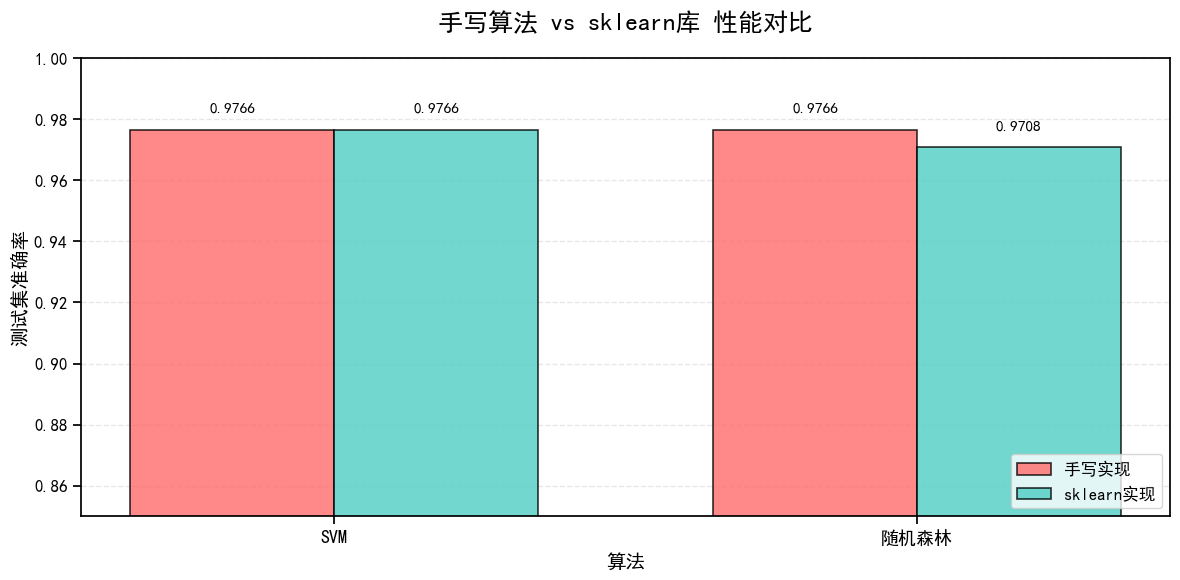

✓ 可视化完成！


In [444]:
# 设置中文字体
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# 准备数据
algorithms = ['SVM', '随机森林']
my_scores = [my_svm_acc, my_rf_acc]
sklearn_scores = [sklearn_svm_acc, sklearn_rf_acc]

# 创建图表
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(algorithms))
width = 0.35

bars1 = ax.bar(x - width/2, my_scores, width, label='手写实现', 
               color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, sklearn_scores, width, label='sklearn实现', 
               color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.2)

# 设置标题和标签
ax.set_title('手写算法 vs sklearn库 性能对比', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('算法', fontsize=14, fontweight='bold')
ax.set_ylabel('测试集准确率', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(algorithms, fontsize=13, fontweight='semibold')
ax.set_ylim(0.85, 1.0)
ax.legend(fontsize=12, loc='lower right')

# 在柱子上显示数值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# 美化
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("✓ 可视化完成！")


# 5. 模型深度优化：SVM (RBF) 与 随机森林特征筛选

在此阶段，我们将进行两个关键的优化操作：
1.  **SVM 优化**：改用 **RBF (高斯) 核函数**，通过网格搜索寻找最佳参数，以捕捉数据中的非线性关系。
2.  **随机森林优化与瘦身**：先对随机森林进行调优，然后利用其特征重要性筛选出“黄金特征”，**重新训练一个轻量级的随机森林模型**，验证是否能用更少的特征实现同等性能。



In [445]:
import numpy as np
import matplotlib.pyplot as plt

class OptimizedSVM:
    """
    优化版SVM - 支持RBF核函数 (手写实现)
    使用对偶问题的梯度上升法求解
    """
    
    def __init__(self, kernel='rbf', C=1.0, gamma='auto', learning_rate=0.01, n_iterations=500):
        """
        参数:
            kernel: 'linear' 或 'rbf'
            C: 正则化参数（越大越不容忍错误，容易过拟合；越小越容忍错误）
            gamma: RBF核参数（控制高斯分布的宽度，'auto'表示1/n_features）
            learning_rate: 学习率
            n_iterations: 迭代次数
        """
        self.kernel = kernel
        self.C = C
        self.gamma = gamma
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.alpha = None  # 拉格朗日乘子 (Dual coefficients)
        self.b = 0         # 偏置
        self.X_train = None
        self.y_train = None
        self.losses = []
        
    def _rbf_kernel(self, X1, X2):
        """
        RBF核函数 (向量化实现)
        K(x, x') = exp(-gamma * ||x - x'||^2)
        """
        # 确保 gamma 已设置
        if self.gamma == 'auto':
            self.gamma = 1.0 / X1.shape[1]

        # 计算欧氏距离的平方: ||x - x'||^2 = ||x||^2 + ||x'||^2 - 2<x, x'>
        # 这种写法利用了广播机制，计算速度快
        X1_norm = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
        X2_norm = np.sum(X2 ** 2, axis=1).reshape(1, -1)
        
        # 欧氏距离平方矩阵
        sq_dists = X1_norm + X2_norm - 2 * np.dot(X1, X2.T)
        
        # RBF 公式
        return np.exp(-self.gamma * sq_dists)
    
    def _linear_kernel(self, X1, X2):
        """线性核函数"""
        return np.dot(X1, X2.T)
    
    def _compute_kernel(self, X1, X2):
        """根据设置计算核矩阵"""
        if self.kernel == 'rbf':
            return self._rbf_kernel(X1, X2)
        else:
            return self._linear_kernel(X1, X2)
    
    def fit(self, X, y):
        """
        训练SVM模型
        使用投影梯度上升法 (Projected Gradient Ascent) 优化对偶问题
        """
        n_samples, n_features = X.shape
        
        # 1. 处理 Gamma
        if self.gamma == 'auto':
            self.gamma = 1.0 / n_features
            
        # 2. 转换标签为 -1 和 1
        y_labeled = np.where(y <= 0, -1, 1)
        
        # 3. 保存训练数据（核方法预测时需要用到支持向量）
        self.X_train = X
        self.y_train = y_labeled
        
        # 4. 初始化 Alpha (拉格朗日乘子)
        self.alpha = np.zeros(n_samples)
        self.b = 0
        
        # 5. 预计算核矩阵 K (Gram Matrix)
        print(f"  正在计算核矩阵 ({self.kernel})...")
        K = self._compute_kernel(X, X)
        
        print(f"  开始梯度上升迭代...")
        # 6. 梯度上升优化
        for iteration in range(self.n_iters):
            # 计算梯度: 
            # Dual Objective Function: L(α) = Σα - 0.5 * ΣΣ α_i α_j y_i y_j K(x_i, x_j)
            # Gradient w.r.t α: 1 - y * (K @ (α * y))
            
            # 预测值的一部分 (不含 b): Σ α_j y_j K(x_i, x_j)
            # 这里的 heavy lifting 交给矩阵乘法
            linear_combination = np.dot(K, self.alpha * y_labeled)
            
            # 计算梯度
            gradient = 1 - y_labeled * linear_combination
            
            # 更新 alpha
            self.alpha += self.lr * gradient
            
            # 投影 (Projection) / 剪枝 (Clipping)
            # 约束条件: 0 <= α <= C
            self.alpha = np.clip(self.alpha, 0, self.C)
            
            # 估算损失 (Dual Gap 或 简单的 Hinge Loss 近似)
            # 这里我们记录简单的Hinge Loss用于观察收敛: max(0, 1 - y*f(x))
            loss = np.mean(np.maximum(0, 1 - y_labeled * (linear_combination + self.b)))
            self.losses.append(loss)
            
            # 每100次打印
            if (iteration + 1) % 100 == 0:
                sv_count = np.sum(self.alpha > 1e-5)
                print(f"  迭代 {iteration+1}/{self.n_iters}, 损失: {loss:.4f}, 支持向量数: {sv_count}")
        
        # 7. 计算偏置 b
        # 使用支持向量 (0 < alpha < C) 来计算 b
        # b = mean(y_k - Σ α_j y_j K(x_j, x_k))
        support_vectors_idx = np.where((self.alpha > 1e-5) & (self.alpha < self.C))[0]
        
        if len(support_vectors_idx) > 0:
            # 取部分支持向量计算平均 b
            b_sum = 0
            for idx in support_vectors_idx:
                b_sum += y_labeled[idx] - np.dot(K[idx, :], self.alpha * y_labeled)
            self.b = b_sum / len(support_vectors_idx)
        else:
            # 如果没有严格的支持向量（可能过拟合或C太大），使用所有非零alpha
            non_zero_idx = np.where(self.alpha > 1e-5)[0]
            if len(non_zero_idx) > 0:
                b_sum = 0
                for idx in non_zero_idx:
                    b_sum += y_labeled[idx] - np.dot(K[idx, :], self.alpha * y_labeled)
                self.b = b_sum / len(non_zero_idx)

        print(f"  训练结束. 最终支持向量数: {np.sum(self.alpha > 1e-5)}/{n_samples}")
        return self
    
    def predict(self, X):
        """
        预测新样本
        f(x) = sign(Σ α_i y_i K(x, x_i) + b)
        """
        # 计算测试样本与训练样本的核矩阵: shape (n_test, n_train)
        K_test = self._compute_kernel(X, self.X_train)
        
        # 计算决策函数值
        # (n_test, n_train) @ (n_train, ) -> (n_test, )
        decision = np.dot(K_test, self.alpha * self.y_train) + self.b
        
        # 转换为0/1标签
        return np.where(decision >= 0, 1, 0)
    
    def score(self, X, y):
        """计算准确率"""
        predictions = self.predict(X)
        accuracy = np.sum(predictions == y) / len(y)
        return accuracy
    
    def plot_loss(self):
        """绘制损失曲线"""
        plt.figure(figsize=(10, 5))
        plt.plot(self.losses, linewidth=2, color='#E91E63')
        plt.title(f'手写SVM (RBF核) 训练损失收敛曲线', fontsize=16, fontweight='bold')
        plt.xlabel('迭代次数', fontsize=12)
        plt.ylabel('Hinge Loss', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

print("✓ OptimizedSVM 类定义完成")

✓ OptimizedSVM 类定义完成


开始训练手写 RBF-SVM...
  正在计算核矩阵 (rbf)...
  开始梯度上升迭代...
  迭代 100/1000, 损失: 0.2414, 支持向量数: 367
  迭代 200/1000, 损失: 0.1880, 支持向量数: 300
  迭代 300/1000, 损失: 0.1575, 支持向量数: 253
  迭代 400/1000, 损失: 0.1381, 支持向量数: 227
  迭代 500/1000, 损失: 0.1238, 支持向量数: 208
  迭代 600/1000, 损失: 0.1131, 支持向量数: 197
  迭代 700/1000, 损失: 0.1049, 支持向量数: 188
  迭代 800/1000, 损失: 0.0988, 支持向量数: 180
  迭代 900/1000, 损失: 0.0939, 支持向量数: 175
  迭代 1000/1000, 损失: 0.0895, 支持向量数: 172
  训练结束. 最终支持向量数: 172/398

手写 RBF-SVM 性能评估
训练集准确率: 0.9899 (98.99%)
测试集准确率: 0.9825 (98.25%)

相比线性SVM提升: 0.58%


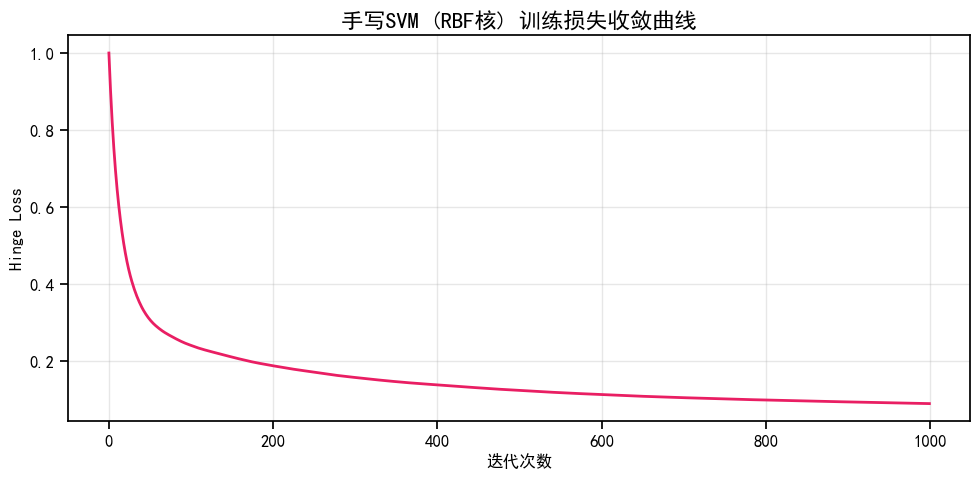


正在对 随机森林 (全特征) 进行随机搜索调优...
✅ 随机森林 最佳参数: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}
✅ 随机森林 最佳验证集得分: 0.9572


In [446]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score

# ==========================================
# 1. SVM 优化 (引入 RBF 核)
# ==========================================

# 1. 初始化模型 (参数可以微调)
# C=1.0, gamma='auto' (自动计算), 学习率稍大一点以便快速收敛
my_opt_svm = OptimizedSVM(kernel='rbf', C=10.0, gamma='auto', learning_rate=0.001, n_iterations=1000)

print("=" * 70)
print("开始训练手写 RBF-SVM...")
print("=" * 70)

# 2. 训练 (注意：这里传入 numpy array)
my_opt_svm.fit(x_train.values, y_train.values)

# 3. 评估
train_acc_opt = my_opt_svm.score(x_train.values, y_train.values)
test_acc_opt = my_opt_svm.score(x_test.values, y_test.values)

print("\n" + "=" * 70)
print("手写 RBF-SVM 性能评估")
print("=" * 70)
print(f"训练集准确率: {train_acc_opt:.4f} ({train_acc_opt*100:.2f}%)")
print(f"测试集准确率: {test_acc_opt:.4f} ({test_acc_opt*100:.2f}%)")

# 与线性SVM对比（如果有记录的话）
if 'train_acc' in globals():
    print(f"\n相比线性SVM提升: {(test_acc_opt - test_acc)*100:.2f}%")

print("=" * 70)

# 4. 绘制损失曲线
my_opt_svm.plot_loss()


# ==========================================
# 2. 随机森林优化 (全特征基准)
# ==========================================
print("\n正在对 随机森林 (全特征) 进行随机搜索调优...")

param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rand_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rand_rf.fit(x_train, y_train)
opt_rf = rand_rf.best_estimator_

print(f"✅ 随机森林 最佳参数: {rand_rf.best_params_}")
print(f"✅ 随机森林 最佳验证集得分: {rand_rf.best_score_:.4f}")

🔎 正在使用测试集进行预测...


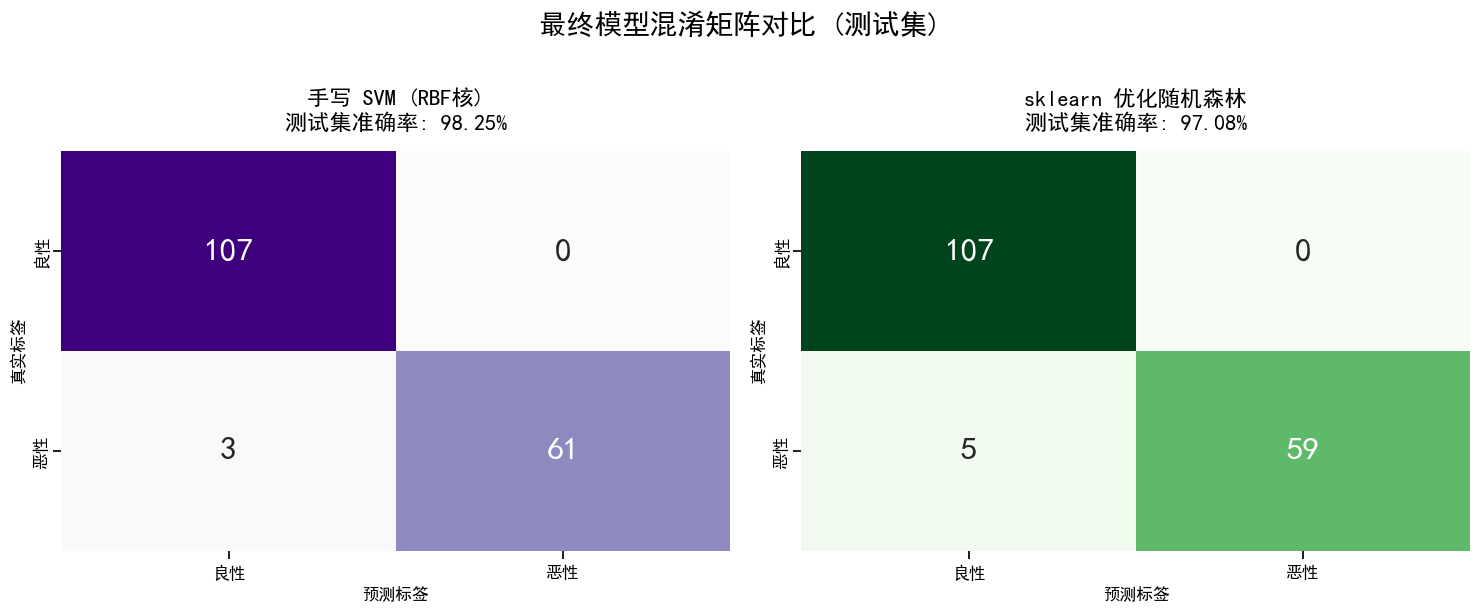

手写 SVM (RBF) 测试集准确率: 0.9825
优化 随机森林    测试集准确率: 0.9708


In [447]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 进行预测
# ==========================================
print("🔎 正在使用测试集进行预测...")

# (A) 手写 SVM 预测 (注意：传入 numpy array)
# 手写模型只能处理数值矩阵，不能处理 DataFrame
y_pred_svm_hand = my_opt_svm.predict(x_test.values)

# (B) 优化随机森林预测 (直接传入 DataFrame)
y_pred_rf_opt = opt_rf.predict(x_test)
y_prob_rf_opt = opt_rf.predict_proba(x_test)[:, 1]  # 获取概率用于 ROC 曲线

# 2. 计算准确率
acc_svm_hand = accuracy_score(y_test, y_pred_svm_hand)
acc_rf_opt = accuracy_score(y_test, y_pred_rf_opt)

# 3. 绘制混淆矩阵
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plt.subplots_adjust(wspace=0.3)

models_viz = [
    {
        "name": "手写 SVM (RBF核)",
        "y_pred": y_pred_svm_hand,
        "acc": acc_svm_hand,
        "ax": axes[0],
        "cmap": "Purples" 
    },
    {
        "name": "sklearn 优化随机森林",
        "y_pred": y_pred_rf_opt,
        "acc": acc_rf_opt,
        "ax": axes[1],
        "cmap": "Greens"
    }
]

for m in models_viz:
    cm = confusion_matrix(y_test, m["y_pred"])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=m["cmap"], ax=m["ax"],
                annot_kws={"size": 24, "weight": "bold"}, cbar=False,
                xticklabels=['良性', '恶性'], yticklabels=['良性', '恶性'])
    
    m["ax"].set_title(f"{m['name']}\n测试集准确率: {m['acc']:.2%}", fontsize=16, fontweight='bold', pad=15)
    m["ax"].set_xlabel('预测标签', fontsize=12, fontweight='bold')
    m["ax"].set_ylabel('真实标签', fontsize=12, fontweight='bold')

plt.suptitle("最终模型混淆矩阵对比 (测试集)", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 50)
print(f"手写 SVM (RBF) 测试集准确率: {acc_svm_hand:.4f}")
print(f"优化 随机森林    测试集准确率: {acc_rf_opt:.4f}")
print("=" * 50)

特征数量(K)    测试集准确率       特征减少比例      
----------------------------------------
5            0.9474        83.3%
10           0.9591        66.7%
15           0.9708        50.0%
20           0.9825        33.3%
25           0.9591        16.7%
30           0.9708        0.0%
----------------------------------------
基准(30个)    0.9708        0.0%


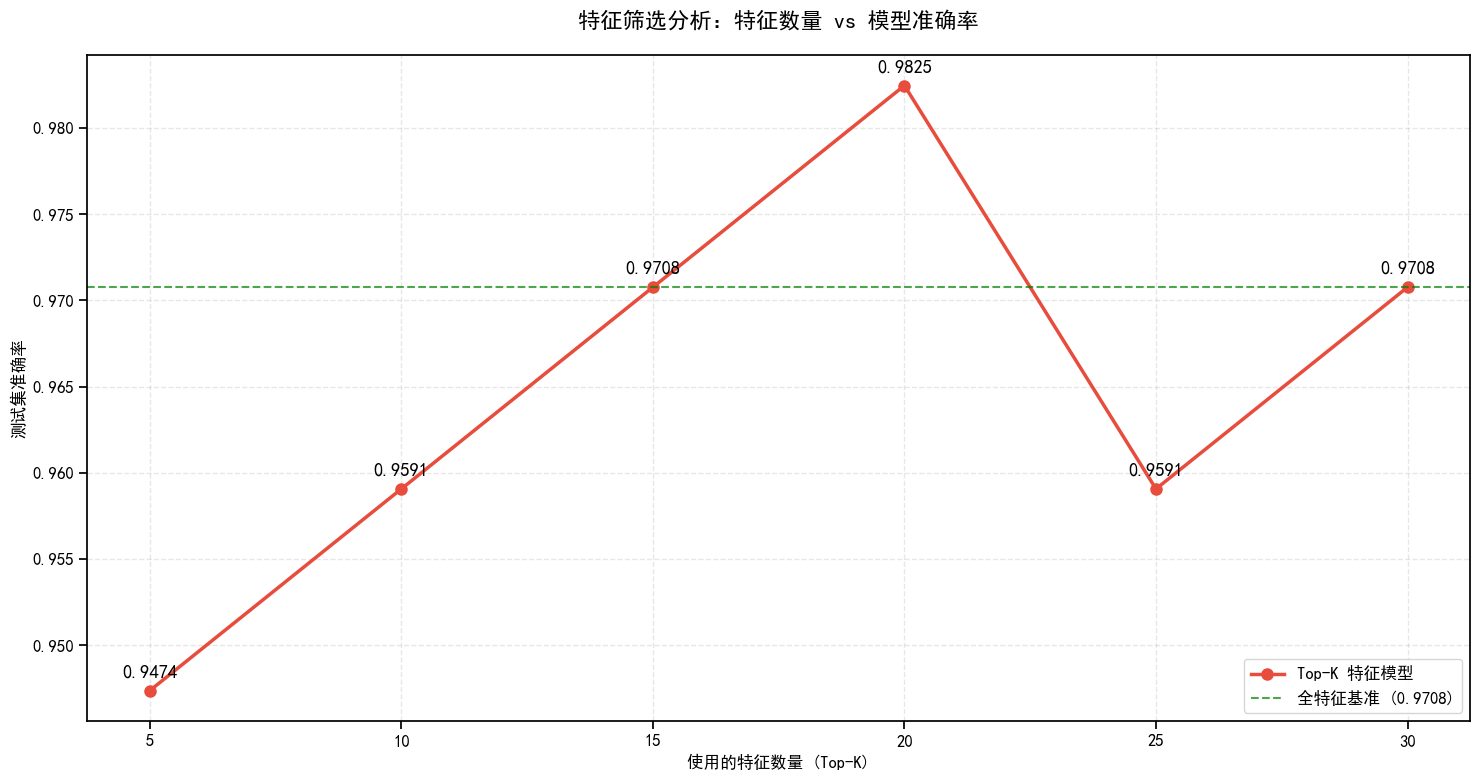

🏆 最佳特征组合: Top-20
   - 准确率: 0.9825
   - 相比全特征: 提升 1.17%
   - 丢弃了 10 个冗余特征 (瘦身 33%)
保留的关键特征列表:
['area_worst', 'concave points_worst', 'perimeter_mean', 'radius_worst', 'perimeter_worst', 'area_mean', 'concave points_mean', 'concavity_mean', 'radius_mean', 'area_se', 'compactness_worst', 'concavity_worst', 'smoothness_worst', 'compactness_mean', 'texture_worst', 'texture_mean', 'perimeter_se', 'symmetry_worst', 'radius_se', 'concavity_se']


In [450]:
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 获取特征重要性排序
# ==========================================
# 使用之前优化好的随机森林模型 opt_rf
importances = opt_rf.feature_importances_
feature_names = x_train.columns

# 创建DataFrame并按重要性降序排序
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# ==========================================
# 2. 循环测试不同数量的特征 (Top-K)
# ==========================================
# 定义我们要测试的特征数量列表
k_values = [5, 10, 15, 20, 25, 30]
results_k = []

print(f"{'特征数量(K)':<10} {'测试集准确率':<12} {'特征减少比例':<12}")
print("-" * 40)

# 记录全特征的基准分数
baseline_acc = opt_rf.score(x_test, y_test)

for k in k_values:
    # 1. 选出重要性排名前 K 的特征名
    top_k_features = feat_df.head(k)['Feature'].tolist()
    
    # 2. 根据这些特征切分数据
    x_train_k = x_train[top_k_features]
    x_test_k = x_test[top_k_features]
    
    # 3. 使用之前调优的最佳参数重新训练模型
    # 注意：这里必须使用新的特征子集重新训练
    rf_k = RandomForestClassifier(random_state=42, **rand_rf.best_params_)
    rf_k.fit(x_train_k, y_train)
    
    # 4. 评估
    acc_k = rf_k.score(x_test_k, y_test)
    reduction = (1 - k / len(feature_names)) * 100
    
    results_k.append({
        'K': k,
        'Accuracy': acc_k,
        'Features': top_k_features
    })
    
    print(f"{k:<12} {acc_k:.4f}        {reduction:.1f}%")

print("-" * 40)
print(f"基准(30个)    {baseline_acc:.4f}        0.0%")

# ==========================================
# 3. 可视化：特征数量 vs 准确率
# ==========================================
df_res = pd.DataFrame(results_k)

plt.figure(figsize=(15, 8))

# 绘制准确率曲线
plt.plot(df_res['K'], df_res['Accuracy'], marker='o', linewidth=2.5, markersize=8, color='#e74c3c', label='Top-K 特征模型')

# 绘制基准线（全特征）
plt.axhline(y=baseline_acc, color='green', linestyle='--', alpha=0.7, label=f'全特征基准 ({baseline_acc:.4f})')

# 标注每个点
for i, row in df_res.iterrows():
    plt.annotate(f"{row['Accuracy']:.4f}", 
                 xy=(row['K'], row['Accuracy']), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontweight='bold')

plt.title('特征筛选分析：特征数量 vs 模型准确率', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('使用的特征数量 (Top-K)', fontsize=12, fontweight='bold')
plt.ylabel('测试集准确率', fontsize=12, fontweight='bold')
plt.xticks(k_values)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 4. 找出性价比最高的模型
# ==========================================
# 策略：找到准确率最高，且特征数最少的组合
best_result = df_res.sort_values(by=['Accuracy', 'K'], ascending=[False, True]).iloc[0]
best_k = int(best_result['K'])
best_acc = best_result['Accuracy']

print("=" * 60)
print(f"🏆 最佳特征组合: Top-{best_k}")
print(f"   - 准确率: {best_acc:.4f}")
print(f"   - 相比全特征: {'提升' if best_acc > baseline_acc else '下降'} {abs(best_acc - baseline_acc)*100:.2f}%")
print(f"   - 丢弃了 {30-best_k} 个冗余特征 (瘦身 {(1-best_k/30)*100:.0f}%)")
print("=" * 60)
print(f"保留的关键特征列表:\n{best_result['Features']}")

# 6. 最终评估可视化

对比 **SVM (RBF)** 和 **精简版随机森林** 的详细表现（ROC曲线与混淆矩阵）。

---

🔎 正在计算预测结果...


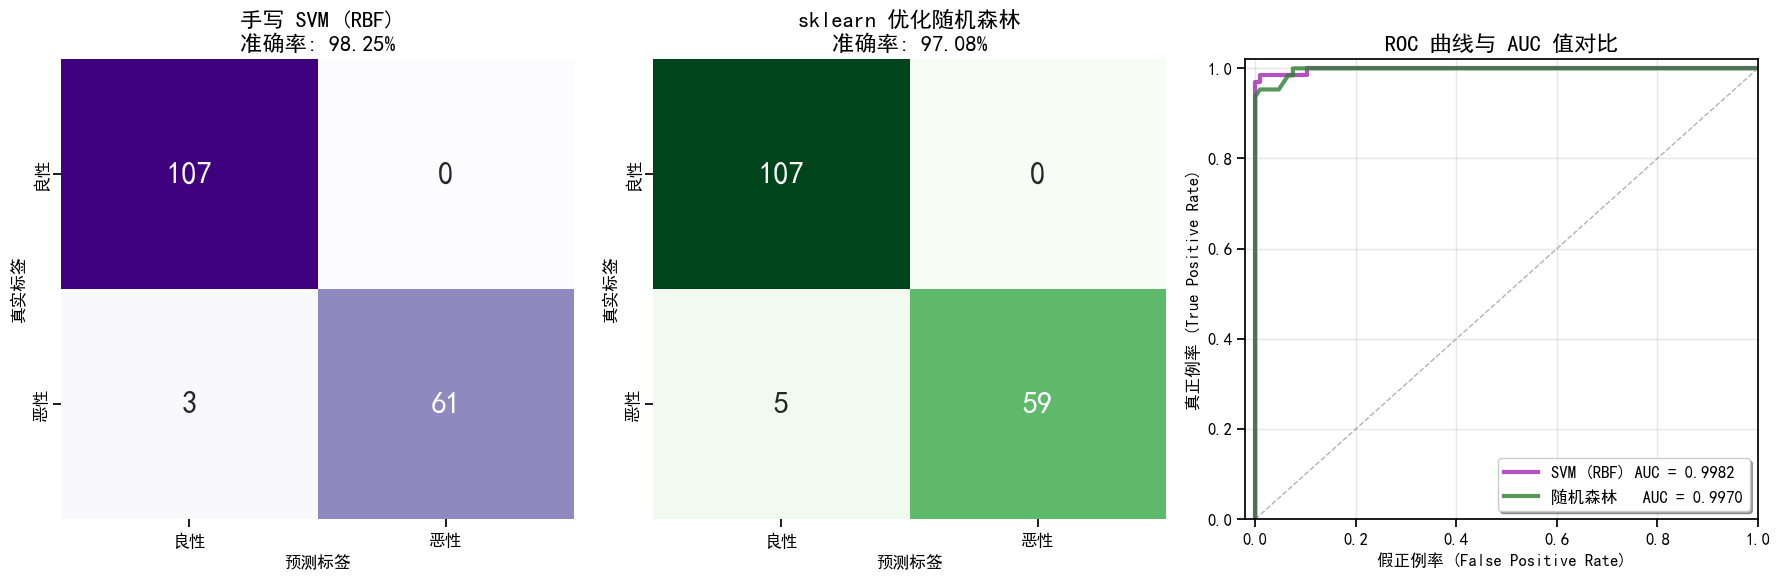

模型名称                 准确率(Accuracy)      AUC 得分         
------------------------------------------------------------
手写 SVM (RBF)         0.9825             0.9982
优化 随机森林              0.9708             0.9970
🏆 最终胜出: [手写 SVM] 在 AUC 指标上表现更好。


In [451]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 修正：确保 SVM 分数计算与 predict 逻辑完全一致
# ==========================================
def compute_svm_scores_robust(model, X_input):
    """
    完全复刻 predict 内部逻辑来计算原始得分 (Distance to Hyperplane)
    """
    # 1. 确保输入是 Numpy 数组
    X = X_input.values if hasattr(X_input, 'values') else X_input
    
    # 2. 确保模型内部存储的训练数据也是 Numpy 数组
    # (这是之前报错的主要原因，这里做防御性转换)
    if hasattr(model.X_train, 'values'):
        X_train_internal = model.X_train.values 
    else:
        X_train_internal = np.array(model.X_train)
        
    # 3. 计算核矩阵 (Test vs Train)
    # 调用模型自带的 _compute_kernel 方法，保证核函数参数一致
    K_test = model._compute_kernel(X, X_train_internal)
    
    # 4. 计算决策值 (不进行符号函数 sign 处理)
    # f(x) = (K * (alpha * y)) + b
    # 这里的逻辑必须与 model.predict 方法里的 dot 顺序一致
    decision_scores = np.dot(K_test, model.alpha * model.y_train) + model.b
    
    return decision_scores

print("🔎 正在计算预测结果...")

# --- A. 手写 SVM (RBF) ---
# 1. 获取原始决策分数 (用于 ROC)
y_score_svm = compute_svm_scores_robust(my_opt_svm, x_test)
# 2. 获取预测类别 (用于 混淆矩阵) -> 逻辑：分数>=0 为类1，<0 为类0
y_pred_svm = np.where(y_score_svm >= 0, 1, 0)

# 计算 SVM 指标
acc_svm = accuracy_score(y_test, y_pred_svm)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# --- B. 优化随机森林 ---
# 1. 获取预测概率 (用于 ROC)
y_prob_rf = opt_rf.predict_proba(x_test)[:, 1]
# 2. 获取预测类别 (用于 混淆矩阵)
y_pred_rf = opt_rf.predict(x_test)

# 计算 RF 指标
acc_rf = accuracy_score(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)


# ==========================================
# 2. 绘制可视化图表
# ==========================================
fig = plt.figure(figsize=(18, 6))

# --- 子图 1: SVM 混淆矩阵 ---
ax1 = plt.subplot(1, 3, 1)
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap="Purples", ax=ax1, cbar=False,
            annot_kws={"size": 22, "weight": "bold"},
            xticklabels=['良性', '恶性'], yticklabels=['良性', '恶性'])
ax1.set_title(f"手写 SVM (RBF)\n准确率: {acc_svm:.2%}", fontsize=16, fontweight='bold')
ax1.set_xlabel('预测标签', fontsize=12)
ax1.set_ylabel('真实标签', fontsize=12)

# --- 子图 2: 随机森林 混淆矩阵 ---
ax2 = plt.subplot(1, 3, 2)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens", ax=ax2, cbar=False,
            annot_kws={"size": 22, "weight": "bold"},
            xticklabels=['良性', '恶性'], yticklabels=['良性', '恶性'])
ax2.set_title(f"sklearn 优化随机森林\n准确率: {acc_rf:.2%}", fontsize=16, fontweight='bold')
ax2.set_xlabel('预测标签', fontsize=12)
ax2.set_ylabel('真实标签', fontsize=12)

# --- 子图 3: ROC 曲线对比 ---
ax3 = plt.subplot(1, 3, 3)
# 绘制 SVM 曲线
ax3.plot(fpr_svm, tpr_svm, color='#9C27B0', lw=3, alpha=0.8, 
         label=f'SVM (RBF) AUC = {auc_svm:.4f}')
# 绘制 RF 曲线
ax3.plot(fpr_rf, tpr_rf, color='#2E7D32', lw=3, alpha=0.8, 
         label=f'随机森林   AUC = {auc_rf:.4f}')
# 绘制对角线
ax3.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.6)

ax3.set_xlim([-0.02, 1.0])
ax3.set_ylim([0.0, 1.02])
ax3.set_xlabel('假正例率 (False Positive Rate)', fontsize=12)
ax3.set_ylabel('真正例率 (True Positive Rate)', fontsize=12)
ax3.set_title('ROC 曲线与 AUC 值对比', fontsize=16, fontweight='bold')
ax3.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 3. 输出最终对比文本
# ==========================================
print("=" * 60)
print(f"{'模型名称':<20} {'准确率(Accuracy)':<18} {'AUC 得分':<15}")
print("-" * 60)
print(f"{'手写 SVM (RBF)':<20} {acc_svm:.4f}             {auc_svm:.4f}")
print(f"{'优化 随机森林':<20} {acc_rf:.4f}             {auc_rf:.4f}")
print("=" * 60)

if auc_svm > auc_rf:
    print(f"🏆 最终胜出: [手写 SVM] 在 AUC 指标上表现更好。")
elif auc_svm < auc_rf:
    print(f"🏆 最终胜出: [随机森林] 在 AUC 指标上表现更好。")
else:
    print(f"🤝 最终结果: 两个模型势均力敌。")

引入这两个模型可以让我们的对比实验更加全面：
1.  **LightGBM**：代表了**Boosting（提升）集成算法**的顶尖水平，通常比随机森林更快、更准。
2.  **神经网络 (MLP)**：代表了**深度学习**的基础，能够捕捉极其复杂的非线性特征。

以下是完整的代码实现，包括模型的构建、训练以及与之前模型的**全面对比可视化**。

In [452]:
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. 定义并训练新模型
# ==========================================
print("🚀 开始训练 LightGBM 和 神经网络...")

# (C) LightGBM 模型
# Boosting 算法，速度快，精度高
lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,     # 树的数量
    learning_rate=0.1,    # 学习率
    num_leaves=31,        # 叶子节点数
    random_state=42,
    verbosity=-1          # 静默模式
)
lgbm_model.fit(x_train, y_train)

# (D) 神经网络 (多层感知机 MLP)
# 简单的全连接神经网络：输入层 -> 隐藏层(64) -> 隐藏层(32) -> 输出层
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32), # 两个隐藏层
    activation='relu',           # 激活函数
    solver='adam',               # 优化器
    alpha=0.0001,                # L2正则化
    max_iter=1000,               # 最大迭代次数
    random_state=42
)
mlp_model.fit(x_train, y_train)

print("✅ 新模型训练完成！")

🚀 开始训练 LightGBM 和 神经网络...
✅ 新模型训练完成！


模型名称                 AUC 得分    
-----------------------------------
手写 SVM (RBF)           0.99825
随机森林 (Opt)             0.99701
LightGBM               0.99562
神经网络 (MLP)             0.99591
-----------------------------------


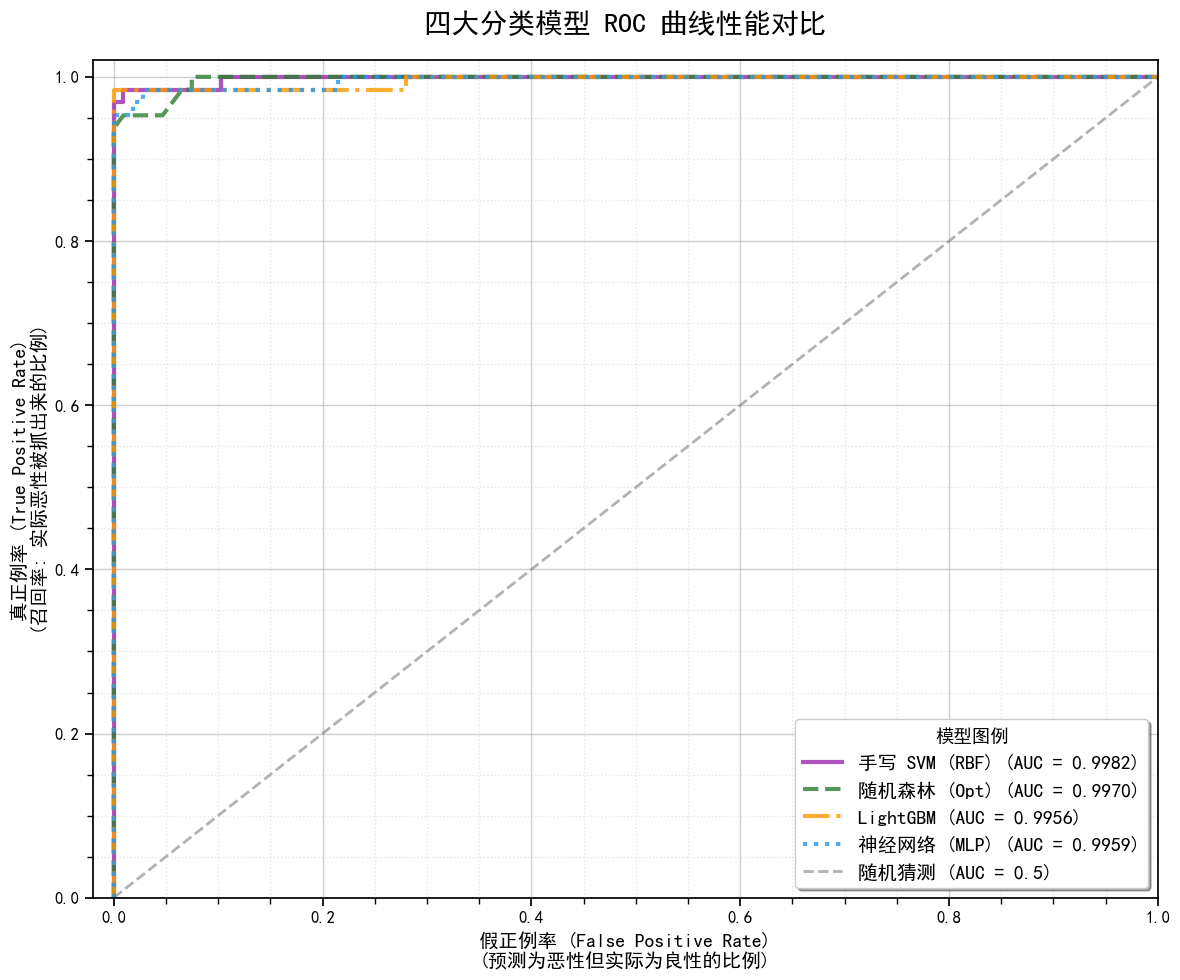

In [454]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

# 设置画布大小
plt.figure(figsize=(12, 10))

# ==========================================
# 1. 准备绘图数据
# ==========================================
# 定义模型列表，包含名称、预测分数获取方式和颜色
# 注意：SVM 需要用决策函数值，其他模型用 predict_proba
plot_data = []

# (1) 手写 SVM (RBF)
# 确保之前定义的计算分数的函数存在
if 'my_opt_svm' in globals():
    # 使用之前定义的函数获取原始距离分数
    svm_scores = calculate_decision_score_correctly(my_opt_svm, x_test) 
    plot_data.append({
        "name": "手写 SVM (RBF)",
        "scores": svm_scores,
        "color": "#9C27B0",  # 紫色
        "style": "-"
    })

# (2) 优化随机森林
if 'opt_rf' in globals():
    plot_data.append({
        "name": "随机森林 (Opt)",
        "scores": opt_rf.predict_proba(x_test)[:, 1],
        "color": "#2E7D32",  # 绿色
        "style": "--"
    })

# (3) LightGBM
if 'lgbm_model' in globals():
    plot_data.append({
        "name": "LightGBM",
        "scores": lgbm_model.predict_proba(x_test)[:, 1],
        "color": "#FF9800",  # 橙色
        "style": "-."
    })

# (4) 神经网络 (MLP)
if 'mlp_model' in globals():
    plot_data.append({
        "name": "神经网络 (MLP)",
        "scores": mlp_model.predict_proba(x_test)[:, 1],
        "color": "#2196F3",  # 蓝色
        "style": ":"
    })

# ==========================================
# 2. 循环绘制曲线
# ==========================================
print(f"{'模型名称':<20} {'AUC 得分':<10}")
print("-" * 35)

for model in plot_data:
    # 计算 FPR, TPR 和 AUC
    fpr, tpr, _ = roc_curve(y_test, model['scores'])
    roc_auc = auc(fpr, tpr)
    
    # 打印数值
    print(f"{model['name']:<22} {roc_auc:.5f}")
    
    # 绘图
    plt.plot(fpr, tpr, 
             color=model['color'], 
             linestyle=model['style'],
             lw=3,  # 线条宽度
             alpha=0.8,
             label=f"{model['name']} (AUC = {roc_auc:.4f})")

print("-" * 35)

# ==========================================
# 3. 美化图表
# ==========================================
# 绘制对角线（随机猜测线）
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', alpha=0.6, label='随机猜测 (AUC = 0.5)')

# 设置范围和标签
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('假正例率 (False Positive Rate)\n(预测为恶性但实际为良性的比例)', fontsize=14, fontweight='bold')
plt.ylabel('真正例率 (True Positive Rate)\n(召回率: 实际恶性被抓出来的比例)', fontsize=14, fontweight='bold')
plt.title('四大分类模型 ROC 曲线性能对比', fontsize=20, fontweight='bold', pad=20)

# 图例和网格
plt.legend(loc="lower right", fontsize=14, frameon=True, shadow=True, title='模型图例')
plt.grid(True, which='major', linestyle='-', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.3)
plt.minorticks_on()

# 显示图表
plt.tight_layout()
plt.show()

📊 正在生成混淆矩阵数据...


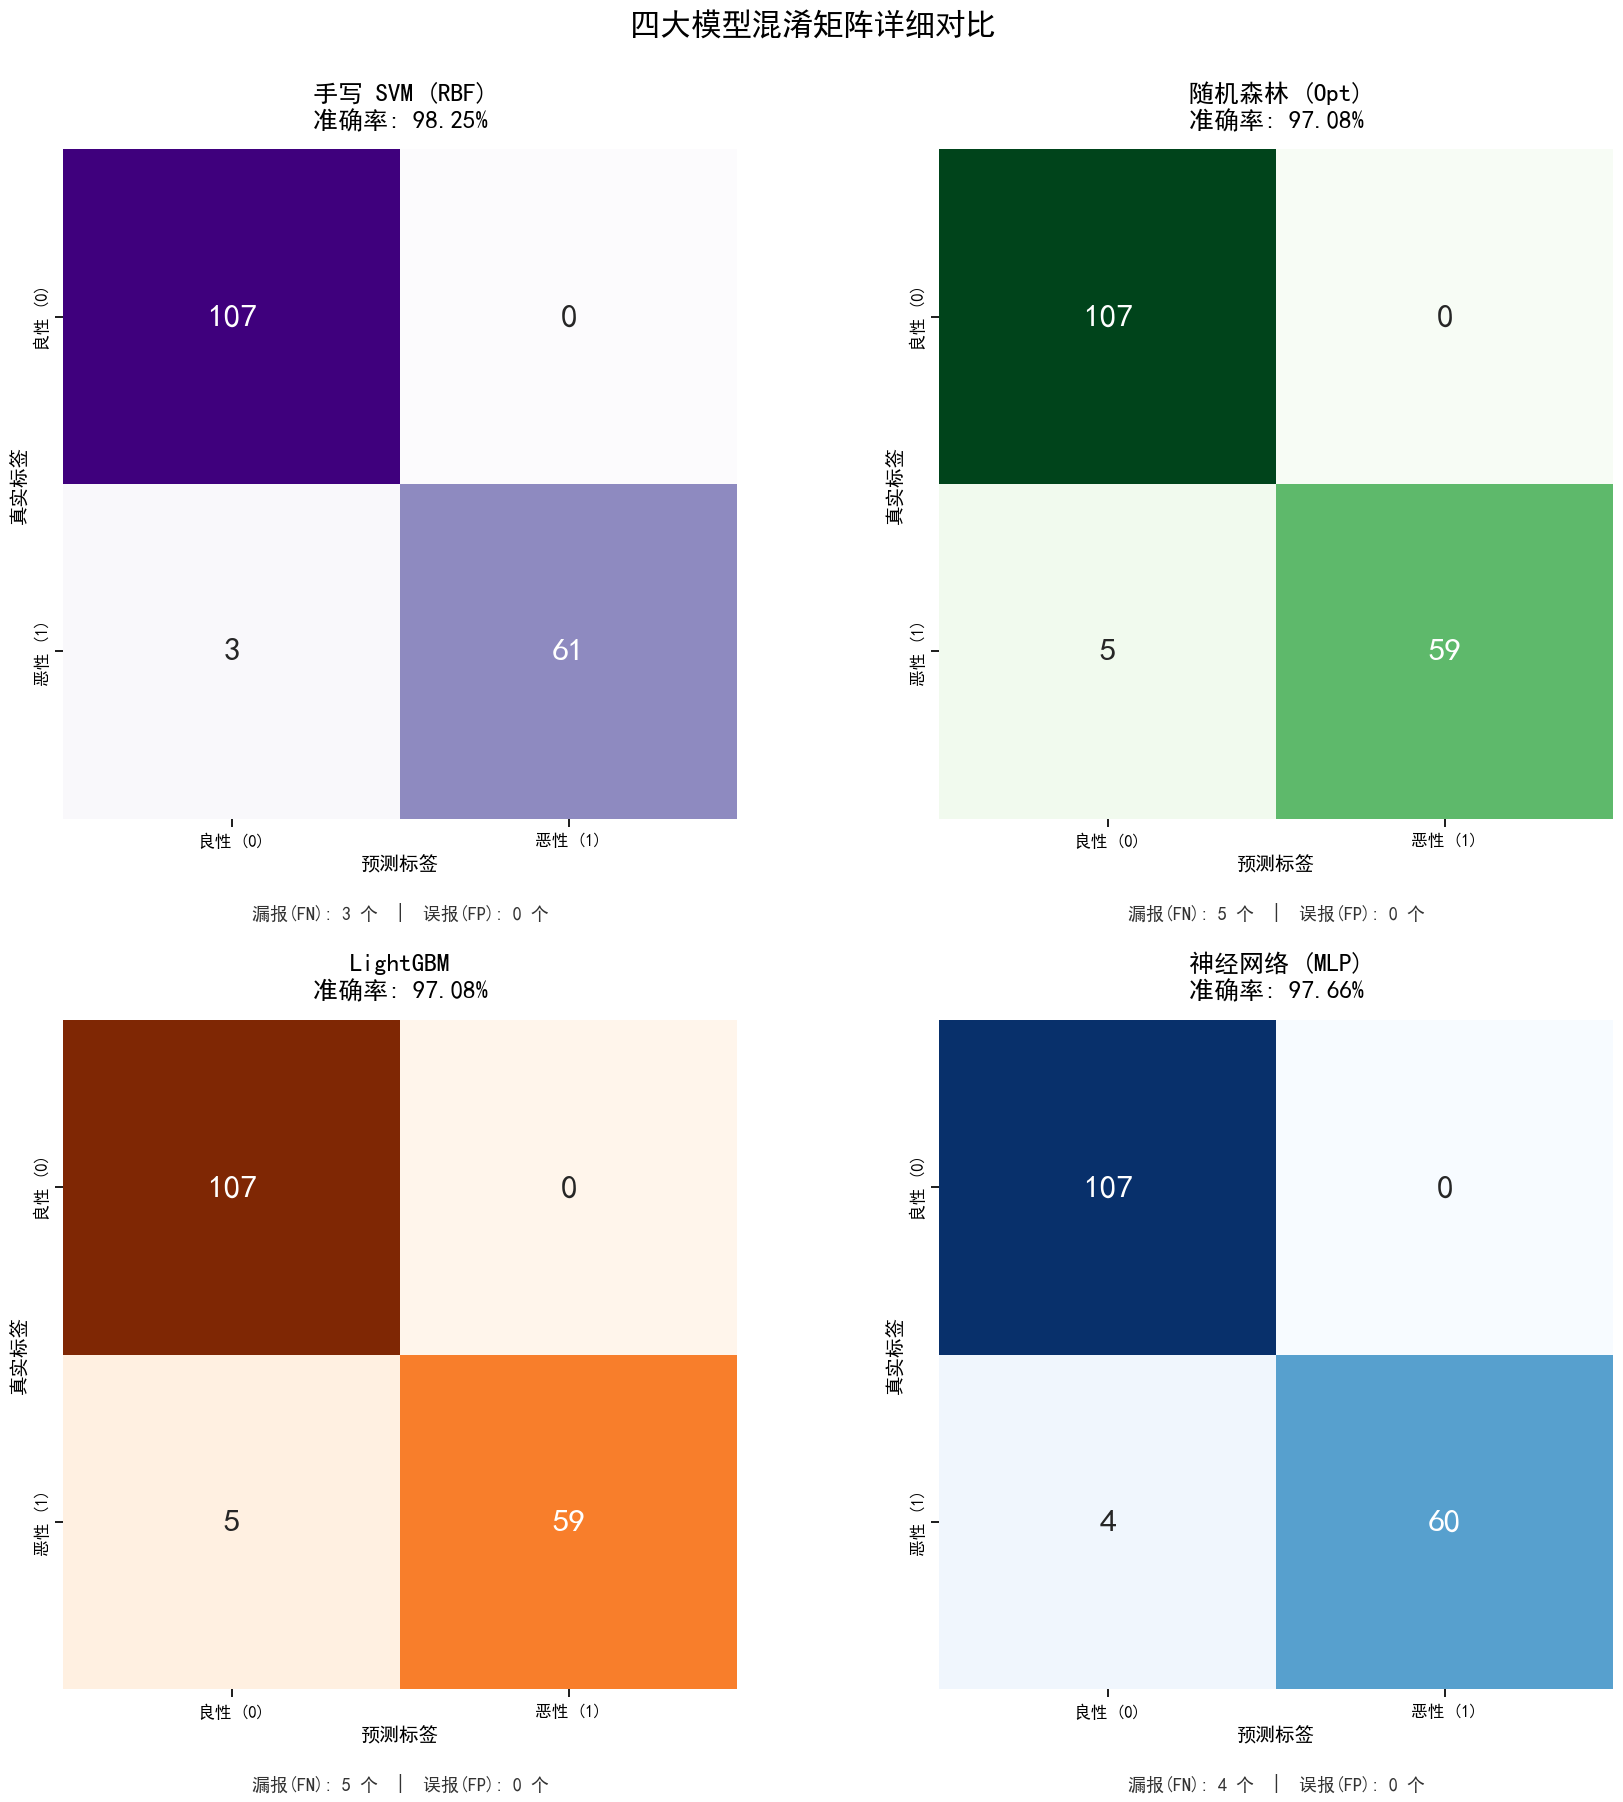

In [457]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 准备预测结果数据
# ==========================================
print("📊 正在生成混淆矩阵数据...")

results_cm = []

# (1) 手写 SVM (RBF)
if 'my_opt_svm' in globals():
    # 使用之前的逻辑计算分数并二值化
    svm_scores = calculate_decision_score_correctly(my_opt_svm, x_test) 
    svm_preds = np.where(svm_scores >= 0, 1, 0)
    results_cm.append({
        "name": "手写 SVM (RBF)",
        "preds": svm_preds,
        "cmap": "Purples"
    })

# (2) 优化随机森林
if 'opt_rf' in globals():
    results_cm.append({
        "name": "随机森林 (Opt)",
        "preds": opt_rf.predict(x_test),
        "cmap": "Greens"
    })

# (3) LightGBM
if 'lgbm_model' in globals():
    results_cm.append({
        "name": "LightGBM",
        "preds": lgbm_model.predict(x_test),
        "cmap": "Oranges"
    })

# (4) 神经网络 (MLP)
if 'mlp_model' in globals():
    results_cm.append({
        "name": "神经网络 (MLP)",
        "preds": mlp_model.predict(x_test),
        "cmap": "Blues"
    })

# ==========================================
# 2. 绘制 2x2 混淆矩阵图
# ==========================================
# 创建 2行2列 的画布
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
# 调整子图之间的间距
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()  # 展平数组以便循环

for i, model_data in enumerate(results_cm):
    ax = axes[i]
    y_pred = model_data['preds']
    
    # 计算混淆矩阵和准确率
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    # 提取 TN, FP, FN, TP 用于标注
    tn, fp, fn, tp = cm.ravel()
    
    # 绘制热力图
    # annot_kws 设置字体大小
    sns.heatmap(cm, annot=True, fmt='d', cmap=model_data['cmap'], ax=ax,
                annot_kws={"size": 24, "weight": "bold"}, cbar=False,
                xticklabels=['良性 (0)', '恶性 (1)'], 
                yticklabels=['良性 (0)', '恶性 (1)'])
    
    # 设置标题和标签
    ax.set_title(f"{model_data['name']}\n准确率: {acc:.2%}", fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('预测标签', fontsize=14, fontweight='bold')
    ax.set_ylabel('真实标签', fontsize=14, fontweight='bold')
    
    # 添加关键指标注释 (漏报数最为关键)
    ax.text(0.5, -0.15, f"漏报(FN): {fn} 个  |  误报(FP): {fp} 个", 
            ha='center', transform=ax.transAxes, fontsize=13, color='#333333', fontweight='medium')

# 添加总标题
plt.suptitle("四大模型混淆矩阵详细对比", fontsize=22, fontweight='bold', y=0.95)

plt.show()
